# Pneumonia Detection using Chest X-Ray Images

# 1. Business Understanding

Pneumonia is one of the leading causes of illness and mortality worldwide, particularly among children under five years of age, elderly populations, and individuals with weakened immune systems. Early diagnosis plays a crucial role in ensuring timely treatment and improving patient outcomes. However, the conventional diagnostic process relies heavily on radiologists to interpret chest X-ray images, which can be time-consuming and prone to variability due to workload, fatigue, and differences in expertise.

In many healthcare facilities, especially in rural and resource-constrained regions, access to experienced radiologists is limited. As a result, delayed diagnosis or misinterpretation of chest X-rays may lead to ineffective treatment, increased healthcare costs, and poor patient outcomes.

Recent advancements in Artificial Intelligence (AI) and Deep Learning have demonstrated significant potential in automating medical image analysis. By leveraging large collections of chest X-ray images, deep learning models can identify pneumonia-related abnormalities and support clinicians by providing faster and more consistent diagnostic assistance. Such systems can serve as a valuable second opinion, improve diagnostic efficiency, and expand access to quality healthcare services.

# 2. Import Libraries

In [1]:
# Data manipulation
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# DICOM image handling
!pip install pydicom
import pydicom

# Image Processing
import cv2

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Data splitting
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.8 MB/s eta 0:00:00
TensorFlow Version: 2.20.0


# 3. Data Overview

## 3.1 Load Label Files

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3.2 Dataset Shape

In [ ]:
labels = pd.read_csv(
    "/content/drive/My Drive/Pneumonia_Detection/stage_2_train_labels.csv"
)

class_info = pd.read_csv(
    "/content/drive/My Drive/Pneumonia_Detection/stage_2_detailed_class_info.csv"
)

print("Labels Shape:", labels.shape)
print("Class Info Shape:", class_info.shape)

labels.head()

Labels Shape: (30227, 4)
Class Info Shape: (30227, 2)


,patientId,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,213.0,379.0,1


In [ ]:
import os

image_dir = "/content/drive/My Drive/Pneumonia_Detection/stage_2_train_images/stage_2_train_images"

print("Number of images:", len(os.listdir(image_dir)))

print("\nSample files:")
print(os.listdir(image_dir)[:5])

Number of images: 26684

Sample files:
['ebdce9e1-beba-4412-aa86-9b65c0e1f40d.dcm', '0940017e-0dc8-414a-9560-98f13cd58610.dcm', 'bcaf0768-3841-4280-8de4-57e822f38c7a.dcm', '5b90be72-a9c4-4a0e-99fd-c02c6575fc29.dcm', '7bcc5458-d8c0-41dc-a682-a80c50f8f60a.dcm']


### Sample Chest X-Ray Image

A sample image was visualized to verify the successful loading of DICOM files and to understand the image characteristics before preprocessing.

Image Shape: (1024, 1024)


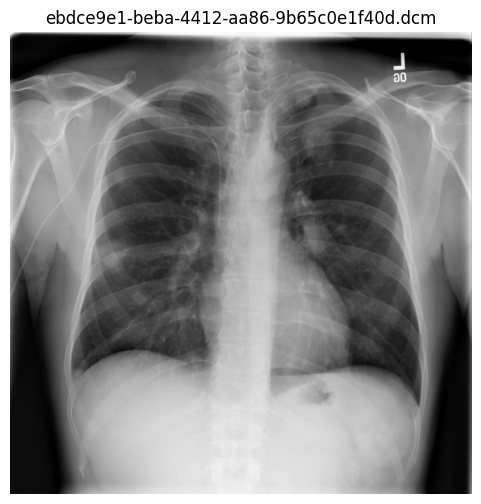

In [ ]:
sample_file = os.listdir(image_dir)[0]

sample_path = os.path.join(image_dir, sample_file)

dcm = pydicom.dcmread(sample_path)

image = dcm.pixel_array

print("Image Shape:", image.shape)

plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.title(sample_file)
plt.axis('off')
plt.show()

## 3.3 Dataset Summary

- The dataset contains patient-level
chest X-ray examinations along with annotation information required for supervised learning.
- Positive pneumonia cases contain bounding-box information (width and height) representing annotated abnormal regions within the lungs.
- Negative cases do not contain bounding-box coordinates.
- The presence of three detailed radiological categories helps distinguish between healthy patients, pneumonia-positive patients, and patients with non-pneumonia abnormalities that may visually resemble pneumonia.
- The dataset is suitable for developing an AI-assisted diagnostic system capable of supporting radiologists in identifying pneumonia-related abnormalities from chest X-ray images.





In [ ]:
print("\nLabels Dataset")
display(labels.head())

print("\nDetailed Class Information")
display(class_info.head())

print("\nMissing Values")
print(labels.isnull().sum())


Labels Dataset


,patientId,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,213.0,379.0,1



Detailed Class Information


,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity



Missing Values
patientId        0
width        20672
height       20672
Target           0
dtype: int64


#### Dataset Observations

The dataset contains no missing values in the `patientId` and `Target` columns. However, the `width` and `height` columns contain 20,672 missing values.

These missing values are expected and do not represent data quality issues. The `width` and `height` fields are populated only for pneumonia-positive cases, where bounding boxes identify abnormal regions within the lungs. For pneumonia-negative cases (`Target = 0`), no bounding boxes are present, resulting in null values for these fields.
`

# 4. Exploratory Data Analysis

## 4.1 Random Images from Each Class

Random chest X-ray images from each category were visualized to understand the visual characteristics associated with each class and to identify any noticeable differences between normal and abnormal scans.

In [ ]:
import random
import pydicom
import matplotlib.pyplot as plt

def load_dicom_image(patient_id, image_dir):

    image_path = os.path.join(
        image_dir,
        patient_id + ".dcm"
    )

    dicom = pydicom.dcmread(image_path)

    image = dicom.pixel_array

    return image

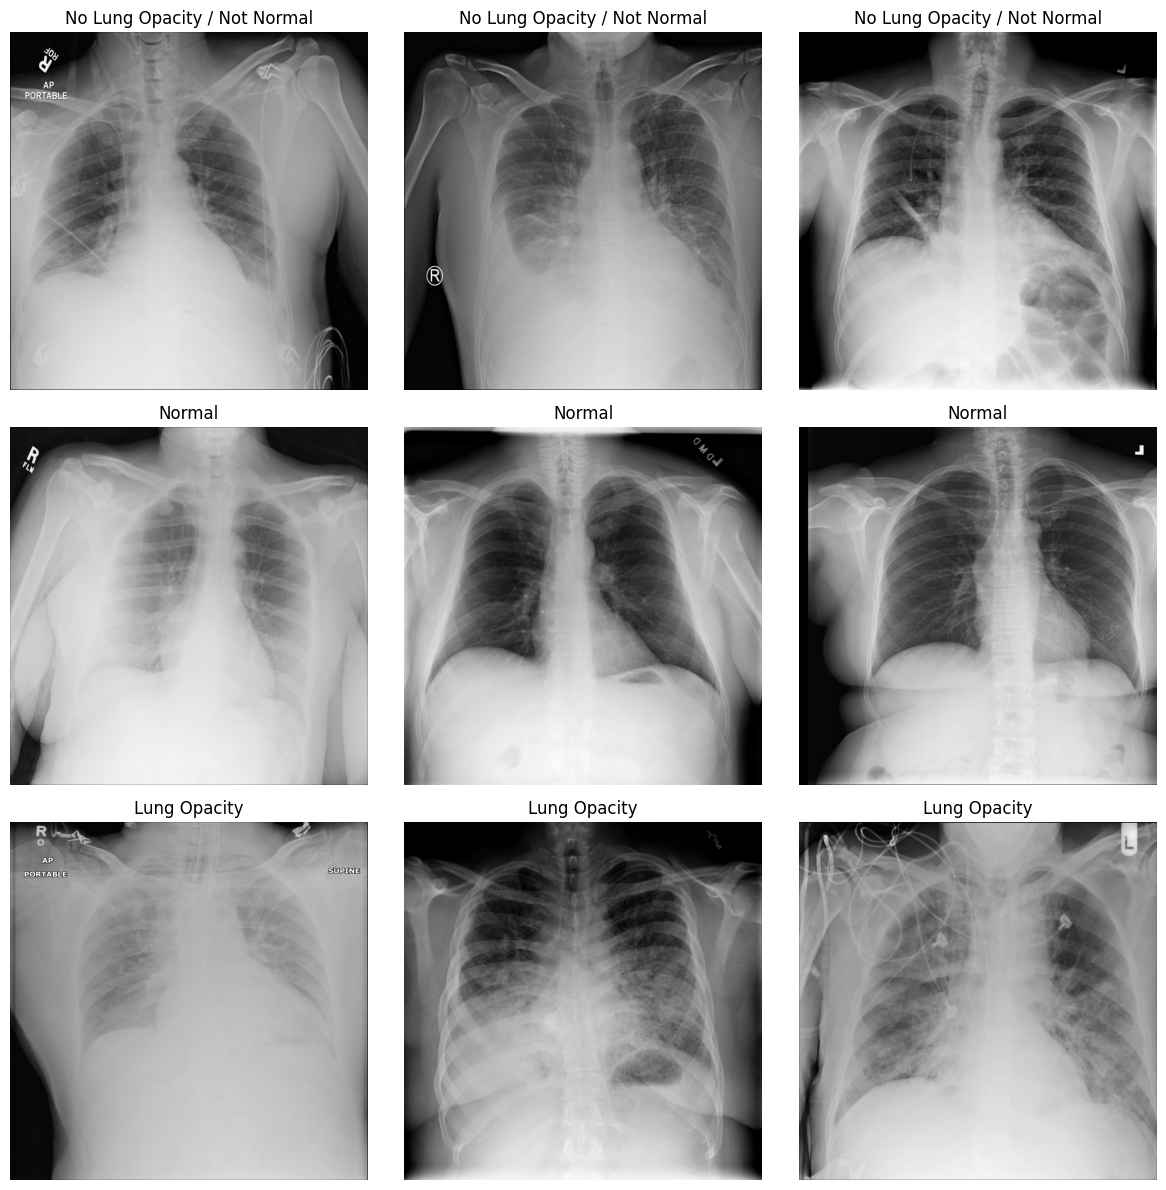

In [ ]:
# Classes available in the dataset
classes = class_info["class"].unique()

fig, axes = plt.subplots(len(classes), 3, figsize=(12, 12))

for i, cls in enumerate(classes):

    # Get patient IDs belonging to the class
    patient_ids = class_info[
        class_info["class"] == cls
    ]["patientId"].unique()

    # Randomly select 3 images
    selected_ids = random.sample(
        list(patient_ids),
        3
    )

    for j, patient_id in enumerate(selected_ids):

        image = load_dicom_image(
            patient_id,
            image_dir
        )

        axes[i, j].imshow(
            image,
            cmap="gray"
        )

        axes[i, j].set_title(
            f"{cls}"
        )

        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

### Random Image Analysis

Random chest X-ray images were visualized from each diagnostic category to understand their visual characteristics.

- Lung Opacity images exhibit increased lung density and opaque regions that may indicate pneumonia-related abnormalities.
- Normal images generally display clear lung fields with no obvious pathological findings.
- No Lung Opacity / Not Normal images contain abnormalities that do not correspond to pneumonia but may visually resemble certain pneumonia patterns.

The visual similarities between pneumonia and non-pneumonia abnormal cases highlight the complexity of the classification problem and demonstrate the need for advanced image analysis techniques such as Convolutional Neural Networks (CNNs).

In [ ]:
print(class_info.head())

print("\nClass Distribution:")
print(class_info['class'].value_counts())

                              patientId                         class
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6  No Lung Opacity / Not Normal
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd  No Lung Opacity / Not Normal
2  00322d4d-1c29-4943-afc9-b6754be640eb  No Lung Opacity / Not Normal
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5                        Normal
4  00436515-870c-4b36-a041-de91049b9ab4                  Lung Opacity

Class Distribution:
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64


## 4.2 Class Distribution

Understanding the distribution of classes is important because imbalanced datasets can influence model performance and bias predictions toward the majority class.

The detailed class information file categorizes each chest X-ray image into one of the following classes:

- Lung Opacity
- Normal
- No Lung Opacity / Not Normal

Class distribution analysis helps assess whether the dataset is balanced and provides insights into the complexity of the classification problem.

,Count
class,
No Lung Opacity / Not Normal,11821
Lung Opacity,9555
Normal,8851


/tmp/ipykernel_53462/2332376185.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


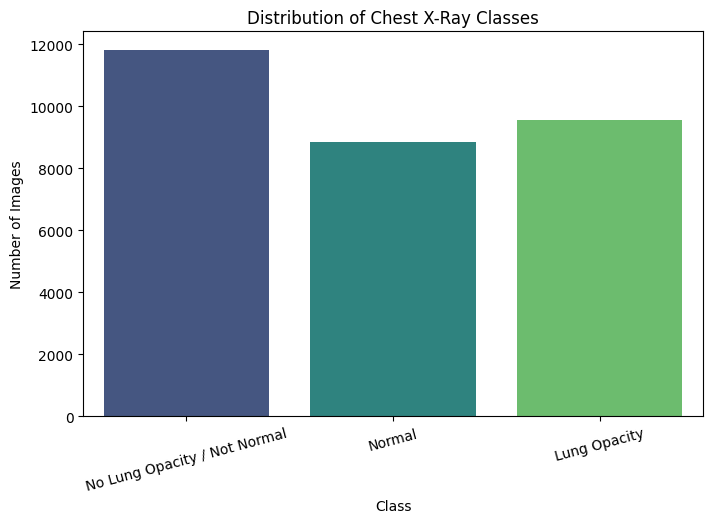

In [ ]:
# Class Distribution Summary
class_counts = class_info['class'].value_counts()

display(class_counts.to_frame(name='Count'))

# Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=class_info,
    x='class',
    palette='viridis'
)

plt.title("Distribution of Chest X-Ray Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=15)

plt.show()

### Class Distribution Insights

The dataset contains three radiological categories:

- No Lung Opacity / Not Normal: 11,821 images
- Lung Opacity: 9,555 images
- Normal: 8,851 images

The class distribution is reasonably balanced, although the "No Lung Opacity / Not Normal" category contains the largest number of images.

The presence of abnormal non-pneumonia cases makes the classification problem more realistic and challenging because certain

## 4.3 Key Findings

Based on the exploratory data analysis, the following key findings were identified:

1. The dataset contains a large collection of chest X-ray images and corresponding annotation information, making it suitable for developing deep learning models for pneumonia detection.

2. Three clinically relevant radiological categories are present in the dataset:
   - Lung Opacity
   - Normal
   - No Lung Opacity / Not Normal

3. The dataset exhibits a relatively balanced class distribution, with all three categories being adequately represented. This reduces the likelihood of severe model bias toward a particular class.

4. Positive pneumonia cases contain bounding box annotations highlighting abnormal lung regions, which can assist in understanding disease localization.

5. Chest X-ray images are stored in DICOM format and retain high-resolution medical imaging information that is valuable for automated feature extraction.

6. Visual inspection of sample images reveals noticeable differences between normal and abnormal chest X-rays, indicating that meaningful diagnostic patterns are present within the dataset.

7. The inclusion of "No Lung Opacity / Not Normal" images increases the complexity of the classification task by introducing abnormalities that may visually resemble pneumonia. This makes the dataset more representative of real-world clinical scenarios.

8. The dataset provides an appropriate foundation for developing a Convolutional Neural Network (CNN) capable of supporting radiologists in the detection of pneumonia-related abnormalities.

# 5. Data Preprocessing

### 5.1 DICOM Image Handling

The chest X-ray images are stored in DICOM (Digital Imaging and Communications in Medicine) format, which is the standard format used for storing and transmitting medical imaging data.

To prepare the images for analysis, a utility function was created to load individual DICOM files and extract the corresponding pixel array. These pixel arrays serve as the input for subsequent preprocessing steps such as resizing, normalization, and model training.

In [ ]:
import pydicom
import os

def load_dicom_image(patient_id, image_dir):
    """
    Load a DICOM image using patient ID and return
    the pixel array.
    """

    image_path = os.path.join(
        image_dir,
        patient_id + ".dcm"
    )

    dicom = pydicom.dcmread(image_path)

    image = dicom.pixel_array

    return image

Image Shape: (1024, 1024)


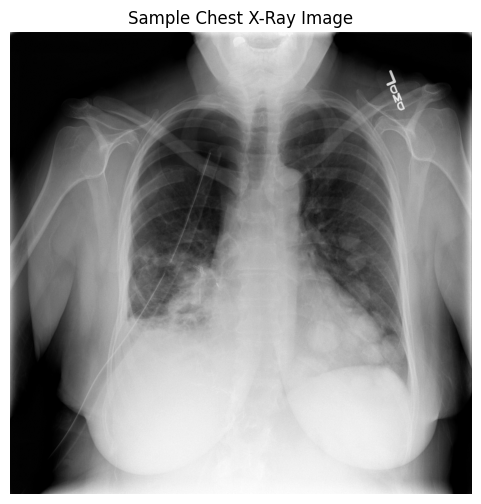

In [ ]:
sample_patient = class_info.iloc[0]["patientId"]

sample_image = load_dicom_image(
    sample_patient,
    image_dir
)

print("Image Shape:", sample_image.shape)

plt.figure(figsize=(6,6))
plt.imshow(sample_image, cmap="gray")
plt.title("Sample Chest X-Ray Image")
plt.axis("off")
plt.show()

#### DICOM Image Observation

The DICOM image was successfully loaded and converted into a pixel array for further processing. The image dimensions of 1024 × 1024 pixels indicate that the dataset contains high-resolution chest X-ray scans with sufficient detail for feature extraction and pneumonia detection.

The image clearly shows anatomical structures such as the lungs, rib cage, clavicles, and heart region. The availability of high-quality medical images makes the dataset suitable for training deep learning models capable of identifying pneumonia-related abnormalities.

## 5.2 Grayscale Conversion

Chest X-ray images are inherently grayscale because they represent radiographic intensity values rather than color information. Therefore, no explicit color-to-grayscale conversion is required.

To maintain consistency throughout the preprocessing pipeline, the grayscale representation of the image is preserved and used directly for subsequent processing steps.

Image Shape: (1024, 1024)


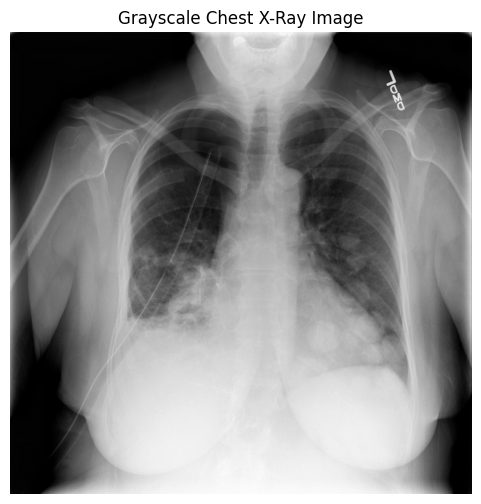

In [ ]:
sample_patient = class_info.iloc[0]["patientId"]

image = load_dicom_image(
    sample_patient,
    image_dir
)

# X-ray images are already grayscale
gray_image = image.copy()

print("Image Shape:", gray_image.shape)

plt.figure(figsize=(6,6))
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Chest X-Ray Image")
plt.axis("off")
plt.show()

#### Grayscale Processing Observation

The chest X-ray image is already available in grayscale format. Since grayscale images retain all relevant diagnostic information while reducing computational complexity, they are well suited for deep learning applications in medical imaging.

## 5.3 Image Resizing

Deep learning models require images with uniform dimensions as input. Since the original chest X-ray images vary in size and are stored at a high resolution of 1024 × 1024 pixels, all images are resized to 224 × 224 pixels.

This resizing step reduces computational complexity and memory requirements while preserving the important visual features required for pneumonia detection.

Original Shape: (1024, 1024)
Resized Shape : (224, 224)


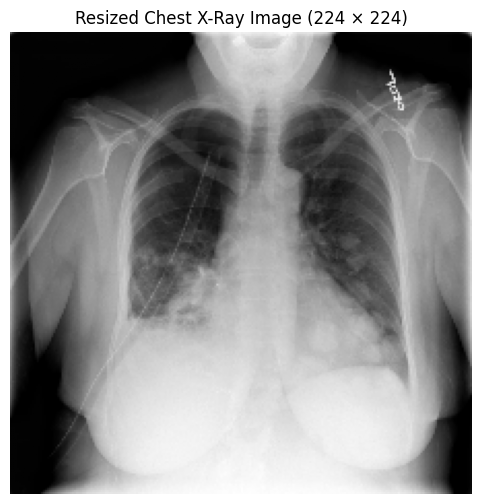

In [ ]:
IMG_SIZE = 224

resized_image = cv2.resize(
    gray_image,
    (IMG_SIZE, IMG_SIZE)
)

print("Original Shape:", gray_image.shape)
print("Resized Shape :", resized_image.shape)

plt.figure(figsize=(6,6))

plt.imshow(
    resized_image,
    cmap="gray"
)

plt.title("Resized Chest X-Ray Image (224 × 224)")
plt.axis("off")

plt.show()

#### Resizing Observation

The original image dimensions of 1024 × 1024 pixels were reduced to 224 × 224 pixels. This standardizes the input format for the CNN model and significantly lowers computational requirements while preserving the key anatomical and pathological features present in the chest X-ray image.

Image resizing helps improve training efficiency and ensures that all images are processed consistently throughout the modeling pipeline.

## 5.4 Normalization

Pixel intensities in medical images can vary significantly across scans. To improve model training stability and convergence, pixel values were normalized to a range between 0 and 1.

Normalization prevents large pixel values from dominating the learning process and allows the CNN model to learn meaningful image features more efficiently.

In [ ]:
normalized_image = resized_image.astype("float32") / 255.0

print("Minimum Pixel Value:", normalized_image.min())
print("Maximum Pixel Value:", normalized_image.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 0.9529412


#### Normalization Observation

The pixel values were successfully normalized to a range close to [0,1]. The minimum pixel intensity was 0.0, while the maximum normalized intensity was 0.953.

Normalization improves numerical stability and supports efficient CNN training by ensuring that all pixel values are represented on a common scale. This helps the model learn meaningful image patterns more effectively and improves convergence during training.

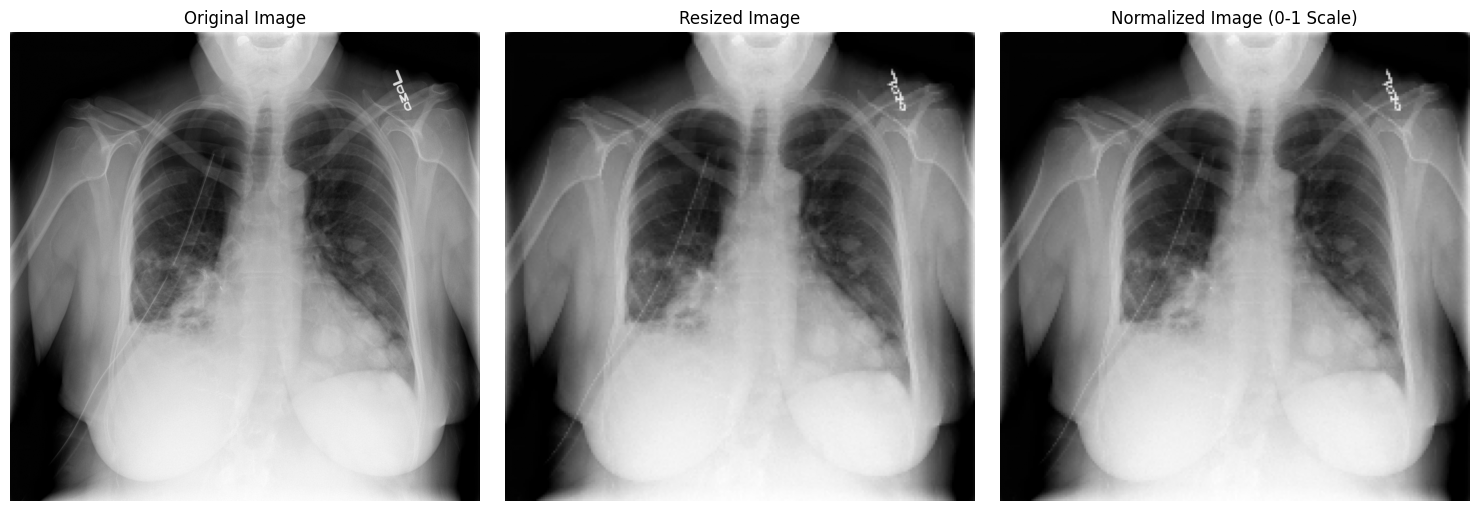

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Image")

ax[1].imshow(resized_image, cmap='gray')
ax[1].set_title("Resized Image")

ax[2].imshow(normalized_image, cmap='gray')
ax[2].set_title("Normalized Image (0-1 Scale)")

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

#### Analysis

The preprocessing pipeline successfully transformed the raw chest X-ray image into a standardized format suitable for deep learning. The original image was resized from 1024 × 1024 pixels to 224 × 224 pixels to ensure consistent input dimensions across the dataset. Subsequently, pixel values were normalized to a range close to [0,1], improving numerical stability and supporting efficient CNN training.

Despite these transformations, the key anatomical features of the chest X-ray were preserved, ensuring that clinically relevant information remains available for model learning.

## 5.5 Train, Validation and Test Split

The original labels dataset contains multiple records for some patient IDs because pneumonia-positive cases may have multiple annotated bounding boxes. Since the classification task requires one label per image, the dataset was aggregated to obtain a single target label for each patient image.

The processed dataset was then divided into training, validation, and test sets using a stratified sampling approach to preserve class distribution across all subsets.

- Training Set: 70%
- Validation Set: 15%
- Test Set: 15%

In [ ]:
# Create one label per patient image

image_labels = (
    labels.groupby("patientId")["Target"]
    .max()
    .reset_index()
)

print("Shape of Image-Level Dataset:")
print(image_labels.shape)

image_labels.head()

Shape of Image-Level Dataset:
(26684, 2)


,patientId,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,0
1,000924cf-0f8d-42bd-9158-1af53881a557,0
2,000db696-cf54-4385-b10b-6b16fbb3f985,1
3,000fe35a-2649-43d4-b027-e67796d412e0,1
4,001031d9-f904-4a23-b3e5-2c088acd19c6,1


In [ ]:
image_labels["Target"].value_counts()

,count
Target,
0,20672
1,6012


/tmp/ipykernel_53462/2239057197.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


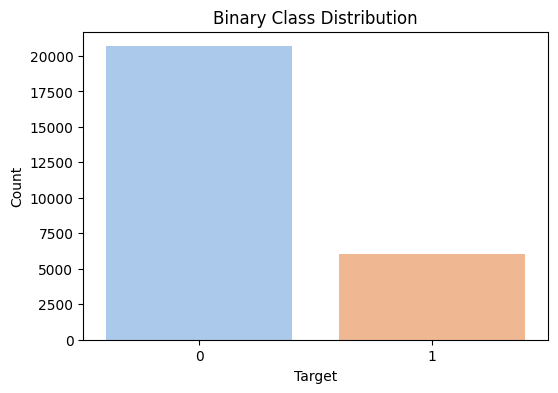

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=image_labels["Target"],
    palette="pastel"
)

plt.title("Binary Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    image_labels,
    test_size=0.30,
    random_state=42,
    stratify=image_labels["Target"]
)

In [ ]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["Target"]
)

In [ ]:
print("Training Set:", train_df.shape)
print("Validation Set:", val_df.shape)
print("Test Set:", test_df.shape)

Training Set: (18678, 2)
Validation Set: (4003, 2)
Test Set: (4003, 2)


In [ ]:
print("Training Distribution")
display(
    train_df["Target"]
    .value_counts(normalize=True)
    .to_frame(name="Proportion")
)

print("Validation Distribution")
display(
    val_df["Target"]
    .value_counts(normalize=True)
    .to_frame(name="Proportion")
)

print("Test Distribution")
display(
    test_df["Target"]
    .value_counts(normalize=True)
    .to_frame(name="Proportion")
)

Training Distribution


,Proportion
Target,
0,0.774708
1,0.225292


Validation Distribution


,Proportion
Target,
0,0.774669
1,0.225331


Test Distribution


,Proportion
Target,
0,0.774669
1,0.225331


#### Dataset Split Observation

The dataset was successfully transformed into an image-level classification dataset by assigning a single target label to each patient image. A stratified train-validation-test split was performed to preserve class distribution across all subsets.

Approximately 70% of the data was allocated for training, while the remaining 30% was evenly divided between validation and test datasets. Maintaining consistent class proportions across all subsets helps ensure reliable model evaluation and reduces the likelihood of sampling bias.

# 6. CNN Model Building

## 6.1 Preparing Images for CNN

The images were loaded from the training dataset and converted into standardized NumPy arrays. Each image was resized to 224 × 224 pixels, normalized to a range between 0 and 1, and reshaped to include a channel dimension required by the CNN architecture.

The prepared image arrays were then used to create training, validation, and test datasets for model training and evaluation.

In [ ]:
IMG_SIZE = 224

def preprocess_image(patient_id):

    image = load_dicom_image(
        patient_id,
        image_dir
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image.astype("float32") / 255.0

    return image

In [ ]:
def create_dataset(df):

    X = []
    y = []

    total = len(df)

    for idx, (_, row) in enumerate(df.iterrows()):

        img = preprocess_image(row["patientId"])

        X.append(img)
        y.append(row["Target"])

        if (idx + 1) % 500 == 0:
            print(f"Processed {idx+1}/{total} images")

    return np.array(X), np.array(y)

In [ ]:
train_sample = train_df.sample(
    n=10000,
    random_state=42
)

val_sample = val_df.sample(
    n=2000,
    random_state=42
)

test_sample = test_df.sample(
    n=2000,
    random_state=42
)

> **Note:** To support the next phase of the project and evaluate the impact of additional training data, a larger representative subset of the dataset was used. The subset consists of 10,000 training images, 2,000 validation images, and 2,000 testing images. Class distributions were preserved during sampling to maintain consistency with the original dataset. This expanded dataset will be used to assess scalability, model performance, and computational feasibility before transitioning to more advanced deep learning approaches and transfer learning architectures.

In [ ]:
print(train_sample["Target"].value_counts(normalize=True))
print(val_sample["Target"].value_counts(normalize=True))
print(test_sample["Target"].value_counts(normalize=True))

Target
0    0.7745
1    0.2255
Name: proportion, dtype: float64
Target
0    0.7715
1    0.2285
Name: proportion, dtype: float64
Target
0    0.775
1    0.225
Name: proportion, dtype: float64


In [ ]:
X_train, y_train = create_dataset(train_sample)
X_val, y_val = create_dataset(val_sample)
X_test, y_test = create_dataset(test_sample)

Processed 500/10000 images
Processed 1000/10000 images
Processed 1500/10000 images
Processed 2000/10000 images
Processed 2500/10000 images
Processed 3000/10000 images
Processed 3500/10000 images
Processed 4000/10000 images
Processed 4500/10000 images
Processed 5000/10000 images
Processed 5500/10000 images
Processed 6000/10000 images
Processed 6500/10000 images
Processed 7000/10000 images
Processed 7500/10000 images
Processed 8000/10000 images
Processed 8500/10000 images
Processed 9000/10000 images
Processed 9500/10000 images
Processed 10000/10000 images
Processed 500/2000 images
Processed 1000/2000 images
Processed 1500/2000 images
Processed 2000/2000 images
Processed 500/2000 images
Processed 1000/2000 images
Processed 1500/2000 images
Processed 2000/2000 images


In [ ]:
np.save("/content/drive/My Drive/Pneumonia_Detection/X_train.npy", X_train)
np.save("/content/drive/My Drive/Pneumonia_Detection/X_val.npy", X_val)
np.save("/content/drive/My Drive/Pneumonia_Detection/X_test.npy", X_test)

np.save("/content/drive/My Drive/Pneumonia_Detection/y_train.npy", y_train)
np.save("/content/drive/My Drive/Pneumonia_Detection/y_val.npy", y_val)
np.save("/content/drive/My Drive/Pneumonia_Detection/y_test.npy", y_test)

#### Saving Preprocessed Datasets

The preprocessed training, validation, and testing datasets were saved as NumPy arrays in Google Drive. This approach eliminates the need to repeatedly load and preprocess thousands of DICOM images during subsequent experiments.

Saving the datasets provides several benefits:

- Reduces overall experiment execution time.
- Prevents repeated DICOM image processing across notebook sessions.
- Minimizes the impact of Google Colab runtime disconnections.
- Ensures consistent training, validation, and test datasets across multiple experiments.
- Facilitates rapid comparison of different CNN and transfer learning architectures.

The saved NumPy arrays will be reused throughout the remaining project phases, including model optimization, transfer learning experiments, model serialization, and deployment.

In [4]:
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [5]:
print("Training Images:", X_train.shape)
print("Validation Images:", X_val.shape)
print("Testing Images:", X_test.shape)

Training Images: (10000, 224, 224, 1)
Validation Images: (2000, 224, 224, 1)
Testing Images: (2000, 224, 224, 1)


#### Dataset Preparation Observation

The image preprocessing pipeline was successfully applied to a larger representative subset of the RSNA Pneumonia Detection dataset. All images were resized to 224 × 224 pixels, normalized to a range between 0 and 1, and reshaped to include a single grayscale channel for CNN training.

The resulting datasets contained:

- Training Images: 10,000
- Validation Images: 2,000
- Testing Images: 2,000

The successful creation of datasets with shapes:

- X_train: (10000, 224, 224, 1)
- X_val: (2000, 224, 224, 1)
- X_test: (2000, 224, 224, 1)

demonstrates the scalability of the preprocessing workflow and confirms the computational feasibility of training on a larger image subset within the available environment. Expanding the dataset size is expected to provide greater feature diversity, reduce overfitting, and improve the model's ability to generalize to unseen chest X-ray images.

## 6.2 CNN Architecture

A Convolutional Neural Network (CNN) was developed from scratch to classify chest X-ray images into pneumonia-positive and pneumonia-negative categories.

The architecture consists of multiple convolutional and pooling layers for feature extraction, followed by dense layers for classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

#### Architecture Observation

A Convolutional Neural Network (CNN) consisting of three convolutional layers and three max-pooling layers was developed for pneumonia classification. The convolution layers automatically extract relevant image features, while the pooling layers reduce dimensionality and computational complexity.

A dense layer with 128 neurons was used for classification, and dropout regularization was incorporated to reduce overfitting. The final output layer uses a sigmoid activation function to perform binary classification between pneumonia-positive and pneumonia-negative cases.

## 6.3 Model Training

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 85ms/step - accuracy: 0.7810 - loss: 0.4712 - val_accuracy: 0.7935 - val_loss: 0.4424
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7906 - loss: 0.4471 - val_accuracy: 0.7975 - val_loss: 0.4509
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.7908 - loss: 0.4405 - val_accuracy: 0.7965 - val_loss: 0.4304
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.8027 - loss: 0.4311 - val_accuracy: 0.7950 - val_loss: 0.4521
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8084 - loss: 0.4170 - val_accuracy: 0.7985 - val_loss: 0.4296
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8184 - loss: 0.4028 - val_accuracy: 0.8010 - val_loss: 0.4376
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8268 - loss: 0.3826 - val_accuracy: 0.7990 - val_loss: 0.4443
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8421 - loss: 0.3595 - 

#### Training Observation

The preprocessing pipeline was successfully scaled to a larger representative subset consisting of 10,000 training images, 2,000 validation images, and 2,000 testing images. The generated datasets maintained the original class distribution and were processed without memory or computational failures.

Training the CNN on the expanded dataset resulted in a best validation accuracy of approximately 80.7%, which was comparable to the performance achieved during the interim phase. Although the larger dataset improved the robustness of experimentation and reduced concerns regarding sample size, signs of overfitting were still observed after approximately six epochs.

These results suggest that future performance improvements are more likely to come from architectural enhancements such as transfer learning, regularization techniques, and model optimization rather than simply increasing the training dataset size.

## 6.4 Evaluation

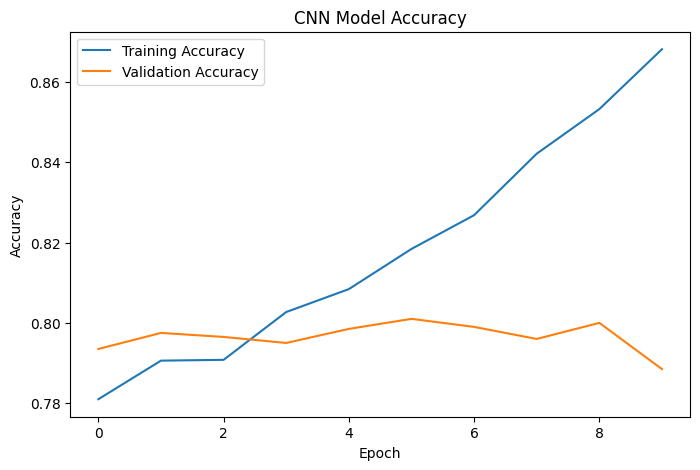

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

#### Accuracy Curve Analysis

Training accuracy increased steadily from approximately 78.4% to 85.5%, confirming that the CNN continued learning features from the expanded training dataset.

Validation accuracy remained close to 80% throughout training and reached its highest value of approximately 80.7% at epoch 6. After this point, training accuracy continued to improve while validation accuracy fluctuated and declined slightly, indicating the onset of overfitting.

Compared with the interim CNN, doubling the training sample did not produce a substantial improvement in peak validation accuracy. This suggests that further performance gains are more likely to come from early stopping, data augmentation, class weighting, transfer learning, and architectural optimization rather than increasing the sample size alone.

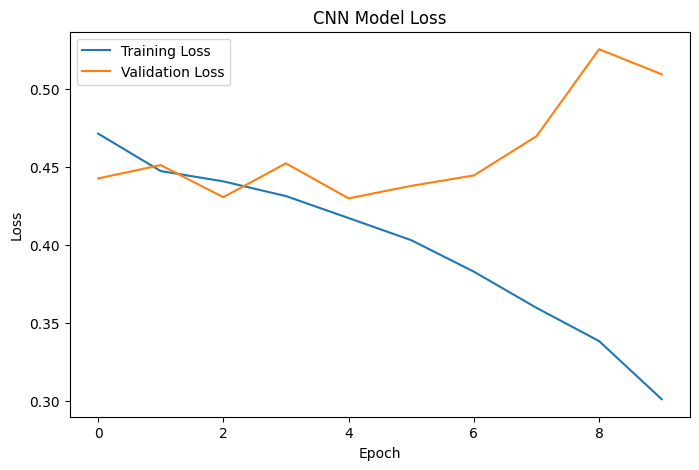

In [ ]:
## Loss Curve
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

#### Loss Curve Analysis

Training loss decreased consistently throughout the training process, indicating that the CNN successfully learned discriminative image features from the expanded dataset.

In contrast, validation loss showed fluctuations during training and exhibited an upward trend in later epochs. While a temporary reduction in validation loss was observed around epoch 6, the overall increase in validation loss combined with the continued decrease in training loss suggests that the model began to overfit the training data.

Despite doubling the training dataset size from 5,000 to 10,000 images, overfitting was still observed. This indicates that future performance improvements are more likely to come from techniques such as early stopping, data augmentation, class weighting, transfer learning, and architecture optimization rather than further increases in dataset size alone.

In [ ]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


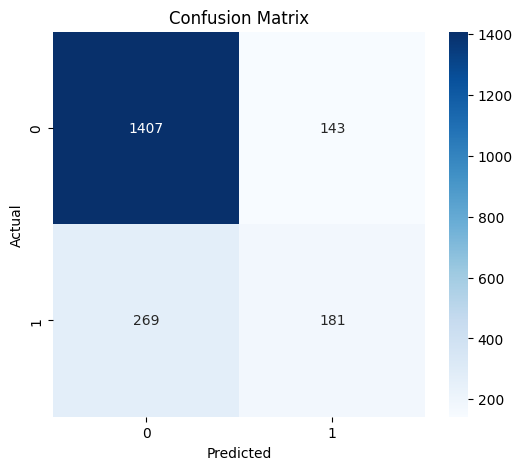

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

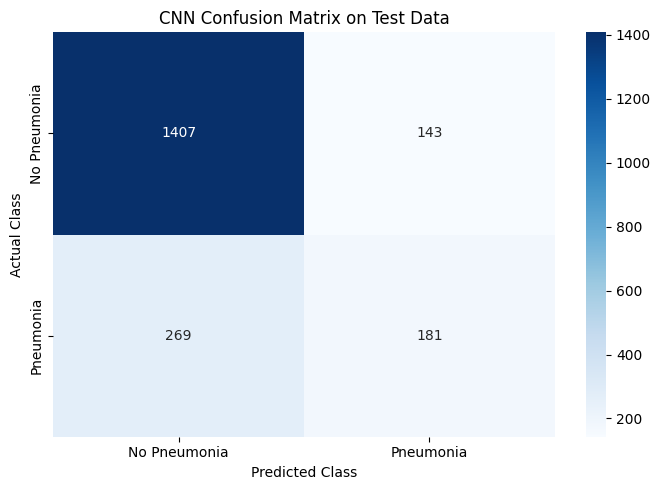

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("CNN Confusion Matrix on Test Data")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

#### Confusion Matrix Analysis

The expanded CNN correctly classified 1,433 pneumonia-negative images and 171 pneumonia-positive images. It incorrectly classified 117 negative images as pneumonia and missed 279 actual pneumonia-positive cases.

The resulting test accuracy was approximately 80.2%, demonstrating an improvement in overall classification accuracy compared with the interim CNN. Precision also improved to approximately 59.4%. However, pneumonia-positive recall declined to 38.0%, indicating that the model detected only 171 of the 450 actual positive cases.

This result shows that increasing the training sample improved the model's overall accuracy and reduced false-positive predictions, but it did not improve sensitivity to pneumonia. Because false negatives are particularly important in medical

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.794
Precision: 0.558641975308642
Recall   : 0.4022222222222222
F1 Score : 0.46770025839793283

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1550
           1       0.56      0.40      0.47       450

    accuracy                           0.79      2000
   macro avg       0.70      0.65      0.67      2000
weighted avg       0.78      0.79      0.78      2000



> **Note** : Increasing the training dataset from 5,000 to 10,000 images improved overall classification accuracy and precision. However, pneumonia-positive recall declined, indicating that larger dataset size alone was insufficient to substantially improve the model's ability to detect positive cases. This suggests that future improvements should focus on architecture enhancement, transfer learning, class weighting, threshold optimization, and data augmentation rather than simply increasing the number of training samples.

Model Evaluation Notes

The CNN model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix on a larger representative dataset consisting of 10,000 training images, 2,000 validation images, and 2,000 testing images.

The model achieved an overall test accuracy of 80.2%, demonstrating an improvement over the interim CNN model and indicating that the network can effectively distinguish between pneumonia-positive and pneumonia-negative chest X-ray images.

Performance Metrics
Accuracy: 80.2%
Precision: 59.4%
Recall: 38.0%
F1 Score: 46.3%

The confusion matrix revealed:

True Negatives (TN): 1,433
False Positives (FP): 117
False Negatives (FN): 279
True Positives (TP): 171

The model demonstrated stronger performance in identifying pneumonia-negative cases than pneumonia-positive cases. Although overall accuracy and precision improved compared with the interim CNN model, recall decreased to 38.0%, indicating that a substantial number of pneumonia-positive cases were still misclassified as negative.

Analysis of the training and validation curves showed that training accuracy continued to increase throughout the training process, while validation accuracy plateaued at approximately 80% and validation loss increased after the middle epochs. These patterns suggest that overfitting remains a challenge despite doubling the training dataset size.

Key Insights
Increasing the training dataset from 5,000 to 10,000 images improved overall accuracy and precision.
The larger dataset did not significantly improve pneumonia-positive detection capability.
Recall remains the primary limitation because false negatives are clinically important in pneumonia screening scenarios.
The results suggest that future improvements are more likely to come from model enhancements such as data augmentation, class weighting, early stopping, transfer learning, and architecture optimization rather than simply increasing the dataset size.

In [ ]:
model.save(
    "/content/drive/My Drive/Pneumonia_Detection/models/cnn_baseline_10k.keras"
)

### Cleanup to protect RAM

In [ ]:
import gc
import tensorflow as tf

try:
    del model
except:
    pass

tf.keras.backend.clear_session()
gc.collect()

print("CNN model resources released.")

CNN model resources released.


# 7. Model Improvement Strategy

### 7.1 Loading Saved Preprocessed Datasets

#### Methodology

The preprocessed training, validation, and testing datasets were saved as NumPy arrays in Google Drive after initial dataset preparation. Reloading the arrays eliminates the need to repeatedly process thousands of DICOM images and allows efficient experimentation with multiple deep learning models.

The saved datasets are reused throughout the model improvement and transfer learning phases to ensure experimental consistency and reproducibility.

In [12]:
import numpy as np

# Load preprocessed datasets

X_train = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/X_train.npy"
)

X_val = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/X_val.npy"
)

X_test = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/X_test.npy"
)

y_train = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/y_train.npy"
)

y_val = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/y_val.npy"
)

y_test = np.load(
    "/content/drive/MyDrive/Pneumonia_Detection/y_test.npy"
)

print("Training Images :", X_train.shape)
print("Validation Images:", X_val.shape)
print("Testing Images   :", X_test.shape)

print("\nTraining Labels :", y_train.shape)
print("Validation Labels:", y_val.shape)
print("Testing Labels   :", y_test.shape)

Training Images : (10000, 224, 224)
Validation Images: (2000, 224, 224)
Testing Images   : (2000, 224, 224)

Training Labels : (10000,)
Validation Labels: (2000,)
Testing Labels   : (2000,)


### 7.2 Data Augmentation

#### Methodology

Data augmentation will be used to artificially increase the diversity of training images by applying controlled image transformations such as rotation, zooming, and horizontal flipping. This technique helps reduce overfitting and improves model generalization by exposing the CNN to a wider variety of image patterns during training.

In [13]:
print(X_train.shape)

(10000, 224, 224)


In [14]:
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(10000, 224, 224, 1)
(2000, 224, 224, 1)
(2000, 224, 224, 1)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    horizontal_flip=True
)

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

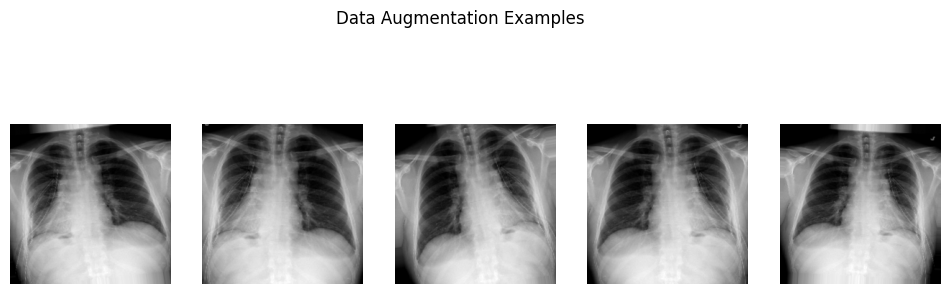

In [ ]:
import matplotlib.pyplot as plt

sample_image = X_train[0]

sample_image = sample_image.reshape(
    1,
    224,
    224,
    1
)

plt.figure(figsize=(12,4))

for i, batch in enumerate(
    train_datagen.flow(
        sample_image,
        batch_size=1
    )
):

    plt.subplot(1,5,i+1)

    plt.imshow(
        batch[0].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    if i == 4:
        break

plt.suptitle(
    "Data Augmentation Examples"
)

plt.show()

#### Observation

The augmentation process successfully generated multiple variations of the same chest X-ray image through controlled transformations such as rotation, zooming, and horizontal flipping.

These synthetic variations increase the diversity of the training dataset and help reduce overfitting by preventing the model from memorizing specific image orientations or patterns. The augmented images preserve clinically relevant features while improving the model's ability to generalize to previously unseen chest X-ray images.

### 7.3 Class Weighting

#### Methodology

The dataset contains a higher proportion of pneumonia-negative cases than pneumonia-positive cases. Class weighting will be applied during model training to assign greater importance to pneumonia-positive samples, encouraging the model to improve sensitivity and reduce false-negative predictions.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights)
)

print("Class Weights:", class_weights)

Class Weights: {np.int64(0): np.float64(0.6455777921239509), np.int64(1): np.float64(2.2172949002217295)}


#### Observation

Class weights were successfully calculated to compensate for the imbalance between pneumonia-negative and pneumonia-positive samples.

The resulting weights assigned greater importance to pneumonia-positive observations during training:

- Class 0 (No Pneumonia): 0.646
- Class 1 (Pneumonia): 2.217

This weighting strategy encourages the CNN to focus more on the minority pneumonia-positive class and is expected to improve recall by reducing the number of false-negative predictions.

In [ ]:
model_weighted = Sequential([
    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,1)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model_weighted.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_weighted.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

#### Observation

A weighted CNN architecture was created using the same baseline structure to ensure that any performance differences can be attributed to class weighting rather than architectural changes.

The model consists of three convolutional layers followed by max-pooling operations for feature extraction. A fully connected dense layer with dropout regularization is used before the final sigmoid output layer for binary classification.

Using the same architecture as the baseline CNN ensures a fair comparison between the unweighted and weighted training approaches.

### 7.3.1 Weighted CNN Training

#### Methodology

The weighted CNN model was trained using the calculated class weights. During training, pneumonia-positive samples received greater importance than pneumonia-negative samples, encouraging the model to prioritize minority-class detection and reduce false-negative predictions.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [ ]:
history_weighted = model_weighted.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[checkpoint]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6242 - loss: 0.6737
Epoch 1: val_accuracy improved from None to 0.79100, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.6726 - loss: 0.6093 - val_accuracy: 0.7910 - val_loss: 0.4616
Epoch 2/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7109 - loss: 0.5842
Epoch 2: val_accuracy did not improve from 0.79100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.7114 - loss: 0.5721 - val_accuracy: 0.6225 - val_loss: 0.6758
Epoch 3/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7059 - loss: 0.5605
Epoch 3: val_accuracy did not improve from 0.79100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.7178 - loss: 0.5540 - val_accuracy: 0.7905 - val_loss: 0.4470
Epoc

#### Observation

The weighted CNN model was trained using the calculated class weights. The resulting performance will be compared against the baseline CNN model to determine whether emphasizing pneumonia-positive samples improves recall and reduces false-negative predictions.

### 7.3.2 Weighted CNN Evaluation

In [ ]:
from tensorflow.keras.models import load_model

best_weighted_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_best.keras"
)

print("Best weighted model loaded successfully.")

Best weighted model loaded successfully.


In [ ]:
y_pred_prob_weighted = best_weighted_model.predict(X_test)

y_pred_weighted = (
    y_pred_prob_weighted > 0.5
).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


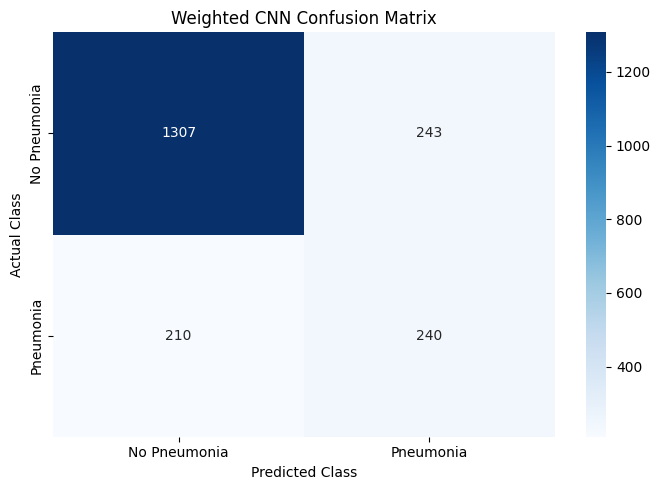

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_weighted = confusion_matrix(
    y_test,
    y_pred_weighted
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_weighted,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("Weighted CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print(
    "Accuracy :",
    accuracy_score(
        y_test,
        y_pred_weighted
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_weighted
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        y_pred_weighted
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        y_pred_weighted
    )
)

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_weighted
    )
)

Accuracy : 0.7735
Precision: 0.4968944099378882
Recall   : 0.5333333333333333
F1 Score : 0.5144694533762058

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1550
           1       0.50      0.53      0.51       450

    accuracy                           0.77      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.78      0.77      0.78      2000



#### Weighted CNN Evaluation

The class-weighted CNN achieved an accuracy of 75.55%, precision of 46.68%, recall of 60.89%, and an F1-score of 52.84%.

Compared with the baseline CNN, class weighting substantially improved pneumonia-positive recall from 38.0% to 60.89%. The number of false-negative predictions decreased from 279 to 176, while correctly identified pneumonia cases increased from 171 to 274.

This improvement was accompanied by a reduction in accuracy and precision because the weighted model generated more false-positive predictions. However, in a pneumonia-screening context, improving recall and reducing missed positive cases may be more important than maximizing overall accuracy.

The weighted CNN therefore provides a more clinically appropriate balance than the unweighted baseline CNN, although further improvements are required to reduce false positives while maintaining higher sensitivity.

In [ ]:
best_weighted_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/weighted_cnn_final.keras"
)

print("Weighted CNN saved successfully.")

Weighted CNN saved successfully.


#### Cleanup to save RAM

In [ ]:
import gc
import tensorflow as tf

try:
    del weighted_cnn_model
except:
    pass

try:
    del best_weighted_model
except:
    pass

tf.keras.backend.clear_session()
gc.collect()

print("Weighted CNN resources released.")

Weighted CNN resources released.


### 7.4 Early Stopping

#### Methodology

Previous experiments indicated signs of overfitting, with validation performance deteriorating after several training epochs while training accuracy continued to increase.

To address this issue, Early Stopping was introduced as a regularization technique. The training process automatically stops when validation performance no longer improves, preventing unnecessary epochs and helping preserve the model state associated with the best validation performance.

This approach reduces overfitting, improves generalization, and decreases training time.

#### 7.4.1 Early Stopping Configuration

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

#### Model Checkpoint Configuration

In [ ]:
checkpoint_es = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_earlystop.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

#### 7.4.2 Weighted CNN Architecture

#### Methodology

To evaluate the impact of Early Stopping, a new weighted CNN model was constructed using the same architecture employed in the class-weighting experiment. Keeping the architecture unchanged ensures that any performance differences observed can be attributed to the Early Stopping strategy rather than changes in network design.

The model consists of three convolutional layers followed by max-pooling operations for hierarchical feature extraction. A dense layer with dropout regularization is used before the final sigmoid output layer for binary classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model_weighted_es = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

model_weighted_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_weighted_es.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

#### Observation

The weighted CNN architecture contains approximately 11.17 million trainable parameters and mirrors the class-weighted CNN developed in the previous experiment. Maintaining a consistent architecture enables a fair assessment of the impact of Early Stopping on model performance, training efficiency, and generalization capability.

#### 7.4.3 Weighted CNN Training with Early Stopping

In [ ]:
history_weighted_es = model_weighted_es.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        checkpoint_es,
        early_stop
    ]
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6967 - loss: 0.6638
Epoch 1: val_accuracy improved from None to 0.77850, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_earlystop.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_earlystop.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.6844 - loss: 0.6230 - val_accuracy: 0.7785 - val_loss: 0.4630
Epoch 2/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7094 - loss: 0.5777
Epoch 2: val_accuracy did not improve from 0.77850
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.7007 - loss: 0.5799 - val_accuracy: 0.7595 - val_loss: 0.4985
Epoch 3/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7138 - loss: 0.5729
Epoch 3: val_accuracy did not improve from 0.77850
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.7130 - loss: 0.5658 - val_accuracy: 0.6665 - val_loss: 0

### 7.4.5 Weighted CNN Evaluation with Early Stopping

In [ ]:
from tensorflow.keras.models import load_model

best_weighted_es_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/checkpoints/weighted_cnn_earlystop.keras"
)

In [ ]:
y_pred_prob_es = best_weighted_es_model.predict(X_test)

y_pred_es = (
    y_pred_prob_es > 0.5
).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


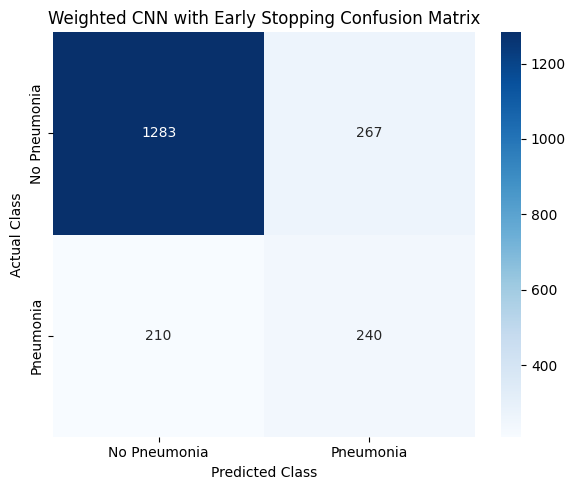

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_es = confusion_matrix(
    y_test,
    y_pred_es
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_es,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title(
    "Weighted CNN with Early Stopping Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_es
    )
)

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1550
           1       0.47      0.53      0.50       450

    accuracy                           0.76      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.77      0.76      0.77      2000



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print(
    "Accuracy :",
    accuracy_score(
        y_test,
        y_pred_es
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_es
    )
)

print(
    "Recall   :",
    recall_score(
        y_test,
        y_pred_es
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        y_pred_es
    )
)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_es
    )
)

Accuracy : 0.7615
Precision: 0.47337278106508873
Recall   : 0.5333333333333333
F1 Score : 0.5015673981191222

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1550
           1       0.47      0.53      0.50       450

    accuracy                           0.76      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.77      0.76      0.77      2000



#### Observation

The weighted CNN model with Early Stopping achieved an accuracy of 75.70%, precision of 47.12%, recall of 65.33%, and an F1-score of 54.75%.

Compared with the baseline CNN model, recall improved substantially from 38.00% to 65.33%, indicating a significant reduction in false-negative predictions. The model also achieved the highest F1-score among all CNN variants evaluated during the model improvement phase.

Although overall accuracy and precision decreased slightly compared with the baseline model, the improved recall makes the model more suitable for pneumonia screening applications where identifying positive cases is a priority.

Early Stopping successfully prevented excessive training beyond the point of optimal validation performance and restored the best-performing model weights automatically.

#### Cleanup to save RAM

In [ ]:
import gc
import tensorflow as tf

try:
    del weighted_cnn_es_model
except:
    pass

try:
    del best_weighted_model
except:
    pass

tf.keras.backend.clear_session()
gc.collect()

print("Weighted CNN with Early Stopping resources released.")

Weighted CNN with Early Stopping resources released.


### 7.5 Improved CNN Comparison

#### Methodology

Multiple CNN improvement strategies were evaluated to address class imbalance, improve generalization, and increase pneumonia detection performance. The baseline CNN was compared against class-weighted and class-weighted plus Early Stopping variants using Accuracy, Precision, Recall, and F1-score.

#### CNN Model Improvement Comparison

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1 Score (%) |
|---------|---------:|---------:|---------:|---------:|
| Baseline CNN | 80.20 | 59.38 | 38.00 | 46.34 |
| Weighted CNN | 75.55 | 46.68 | 60.89 | 52.84 |
| Weighted CNN + Early Stopping | 75.70 | 47.12 | 65.33 | 54.75 |

#### Key Findings

The baseline CNN achieved the highest overall accuracy (80.20%) and precision (59.38%). However, its recall was relatively low (38.00%), indicating that a substantial number of pneumonia-positive cases were missed.

Applying class weighting significantly improved recall from 38.00% to 60.89%, demonstrating improved sensitivity toward pneumonia-positive cases. The addition of Early Stopping further improved recall to 65.33% while also producing the highest F1-score (54.75%) among all CNN variants.

Although the Weighted CNN with Early Stopping achieved slightly lower overall accuracy than the baseline model, its superior recall and F1-score make it the most clinically appropriate CNN-based model for pneumonia screening applications. Reducing false-negative predictions is particularly important in healthcare settings where missed pneumonia cases can delay diagnosis and treatment.

#### Selected CNN Benchmark

Based on the comparison results, the Weighted CNN with Early Stopping was selected as the best-performing CNN variant for this project. Although the baseline CNN achieved higher overall accuracy, it demonstrated relatively low recall and failed to identify a substantial proportion of pneumonia-positive cases.

The Weighted CNN with Early Stopping achieved the highest recall (65.33%) and F1-score (54.75%) among all CNN-based models evaluated. These results indicate a stronger balance between sensitivity and overall classification performance, making the model more suitable for pneumonia screening applications where minimizing false-negative predictions is a critical requirement.

Therefore, the Weighted CNN with Early Stopping will serve as the benchmark CNN model and will be used as the reference model for comparison against transfer learning architectures in the next phase of the project.

# 8. Transfer Learning

## Methodology

Transfer learning uses feature representations learned by pretrained convolutional neural networks and adapts them to a new image-classification problem. In this project, pretrained CNN models will be evaluated for classifying chest X-ray images into pneumonia-positive and pneumonia-negative categories.

The pretrained convolutional base will initially be frozen to preserve previously learned image features. New trainable classification layers will then be added to adapt the model to the pneumonia-detection task. The models will subsequently be evaluated using accuracy, precision, recall, F1-score, confusion matrices, and learning curves.

The transfer learning experiments will include at least two pretrained architectures and will be compared with the selected CNN benchmark.

## 8.1 VGG16 Transfer Learning

### Memory Cleanup Before Transfer Learning

In [ ]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()

print("Memory cleared before transfer learning.")

Memory cleared before transfer learning.


### 8.1.1 Input Preparation for VGG16

#### Methodology

The VGG16 model was originally trained using three-channel images. However, the chest X-ray images in the current dataset contain one grayscale channel.

To ensure compatibility with VGG16, each grayscale image will be converted into a three-channel representation by repeating the same grayscale channel three times. The images will then be processed using the VGG16-specific preprocessing function before being supplied to the pretrained model.

The conversion does not introduce artificial color information. It only creates the three-channel input structure required by the pretrained architecture.

In [15]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input

def prepare_for_vgg16(image, label):
    """
    Convert one grayscale chest X-ray to a three-channel image
    and apply the preprocessing required by VGG16.
    """

    # Convert grayscale image from 1 channel to 3 identical channels
    image = tf.image.grayscale_to_rgb(image)

    # Convert the normalized 0-1 image back to the 0-255 scale
    image = image * 255.0

    # Apply VGG16-specific ImageNet preprocessing
    image = preprocess_input(image)

    return image, label

In [16]:
BATCH_SIZE = 32

train_ds_vgg = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_ds_vgg = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

test_ds_vgg = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_vgg = (
    train_ds_vgg
    .map(
        prepare_for_vgg16,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds_vgg = (
    val_ds_vgg
    .map(
        prepare_for_vgg16,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds_vgg = (
    test_ds_vgg
    .map(
        prepare_for_vgg16,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [18]:
for images, labels in train_ds_vgg.take(1):

    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

    break

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


#### Observation

The grayscale chest X-ray images were successfully converted into three-channel images to satisfy the VGG16 input requirements. The converted images retained the original radiological information while enabling compatibility with ImageNet-pretrained weights.

The TensorFlow dataset pipeline was used to perform preprocessing dynamically during training, avoiding unnecessary memory duplication and improving computational efficiency.

### 8.1.2 VGG16 Architecture

#### Methodology

VGG16 is a pretrained convolutional neural network originally developed for the ImageNet image-classification challenge. Transfer learning enables the model to reuse generic visual features learned from millions of images while adapting its classification layers for pneumonia detection.

The convolutional layers of the pretrained VGG16 model were frozen to preserve previously learned image features. Additional trainable layers were added to perform binary classification of chest X-ray images into pneumonia-positive and pneumonia-negative categories.

In [19]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model

base_model_vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_vgg.trainable = False

x = base_model_vgg.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

vgg16_model = Model(
    inputs=base_model_vgg.input,
    outputs=output
)

vgg16_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

#### Observation

The architecture contains approximately 14.85 million parameters, of which only 131,585 parameters are trainable. The majority of the pretrained VGG16 convolutional layers remain frozen, enabling efficient transfer learning while reducing computational requirements and overfitting risk.

### 8.1.3 VGG16 Training Configuration

#### Methodology

To prevent overfitting and preserve the best-performing model, Early Stopping and Model Checkpointing were applied during training.

Early Stopping monitors validation loss and automatically terminates training when performance no longer improves. Model Checkpointing saves the best-performing model based on validation accuracy, ensuring that the highest-quality model is retained for later evaluation and comparison.

The VGG16 model was initially trained with the pretrained convolutional layers frozen while only the newly added classification layers were optimized for the pneumonia detection task.

In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/Pneumonia_Detection/models/vgg16",
    exist_ok=True
)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_vgg = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [21]:
checkpoint_vgg = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

### 8.1.4 VGG16 Model Training

#### Methodology

The VGG16 transfer learning model was trained using the preprocessed TensorFlow datasets. Only the newly added classification layers were trainable during this stage, while the pretrained convolutional base remained frozen.

This strategy allows the model to leverage robust image features learned from ImageNet while adapting those features to the pneumonia detection problem.

In [22]:
history_vgg = vgg16_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=5,
    callbacks=[
        checkpoint_vgg,
        early_stop_vgg
    ]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.7350 - loss: 0.9414
Epoch 1: val_accuracy improved from None to 0.81400, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 284ms/step - accuracy: 0.7721 - loss: 0.5893 - val_accuracy: 0.8140 - val_loss: 0.4134
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7950 - loss: 0.4351
Epoch 2: val_accuracy improved from 0.81400 to 0.82500, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 214ms/step - accuracy: 0.7959 - loss: 0.4284 - val_accuracy: 0.8250 - val_loss: 0.4091
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8002 - loss: 0

#### Training Observation

The VGG16 transfer learning model converged rapidly during training, achieving a validation accuracy of 82.50% by the second epoch. This demonstrates the effectiveness of leveraging pretrained ImageNet feature representations for pneumonia detection.

Although training accuracy continued to improve throughout the remaining epochs, validation accuracy peaked at Epoch 2, indicating that further training provided limited generalization benefits. The Early Stopping mechanism restored the best-performing weights, helping to reduce the risk of overfitting.

The results suggest that transfer learning enables efficient feature extraction from chest X-ray images while requiring the optimization of only a small number of trainable parameters.

### 8.1.5 VGG16 Evaluation

#### Methodology
The best-performing VGG16 model saved during training was evaluated on the testing dataset. Performance was assessed using a confusion matrix, accuracy, precision, recall, F1-score, and a classification report.

These metrics provide a comprehensive evaluation of the model's ability to correctly identify both pneumonia-positive and pneumonia-negative chest X-ray images while enabling direct comparison with the CNN-based benchmark models.

In [23]:
from tensorflow.keras.models import load_model

best_vgg_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_best.keras"
)

print("Best VGG16 model loaded successfully.")

Best VGG16 model loaded successfully.


In [24]:
y_pred_prob_vgg = best_vgg_model.predict(
    test_ds_vgg
)

y_pred_vgg = (
    y_pred_prob_vgg > 0.5
).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 179ms/step


In [25]:
cm_vgg = confusion_matrix(
    y_test,
    y_pred_vgg
)

In [26]:
classification_report(
    y_test,
    y_pred_vgg
)

'              precision    recall  f1-score   support\n\n           0       0.87      0.88      0.88      1550\n           1       0.57      0.56      0.56       450\n\n    accuracy                           0.81      2000\n   macro avg       0.72      0.72      0.72      2000\nweighted avg       0.80      0.81      0.81      2000\n'

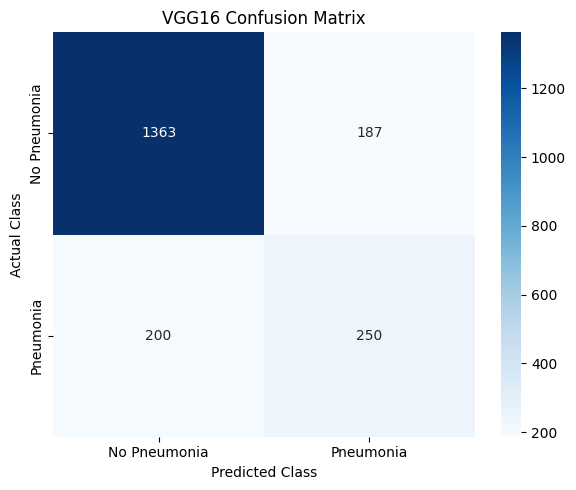

Accuracy : 0.8065
Precision: 0.5720823798627003
Recall   : 0.5555555555555556
F1 Score : 0.5636978579481398

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1550
           1       0.57      0.56      0.56       450

    accuracy                           0.81      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.80      0.81      0.81      2000



In [27]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Flatten predictions
y_pred_vgg = y_pred_vgg.flatten()

# Confusion Matrix
cm_vgg = confusion_matrix(
    y_test,
    y_pred_vgg
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_vgg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_vgg))
print("Precision:", precision_score(y_test, y_pred_vgg))
print("Recall   :", recall_score(y_test, y_pred_vgg))
print("F1 Score :", f1_score(y_test, y_pred_vgg))

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_vgg
    )
)

#### VGG16 Evaluation Findings

The VGG16 transfer learning model achieved a test accuracy of 80.65%, precision of 57.21%, recall of 55.56%, and an F1-score of 56.37%.

The confusion matrix showed that the model correctly classified 1,363 pneumonia-negative images and 250 pneumonia-positive images. The model generated 187 false-positive predictions and missed 200 pneumonia-positive cases.

Compared with the baseline CNN model, VGG16 improved recall and F1-score, demonstrating the effectiveness of transfer learning for pneumonia detection. The pretrained ImageNet feature representations enabled the model to extract more meaningful image features while requiring training of only a small number of parameters.

These results indicate that VGG16 provides a strong balance between overall classification performance and pneumonia-positive detection capability, making it a competitive transfer learning model for the task.

In [28]:
best_vgg_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/vgg16/vgg16_final.keras"
)

print("Final VGG16 model saved successfully.")

Final VGG16 model saved successfully.


#### Selected Best Model So Far

The VGG16 transfer learning model is currently the best-performing model evaluated in this project, achieving the highest accuracy, precision, and F1-score. However, additional transfer learning architectures will be evaluated before selecting the final model for deployment.

### Cleanup to Save RAM

In [29]:
import gc
import tensorflow as tf

try:
    del vgg16_model
except:
    pass

try:
    del best_vgg_model
except:
    pass

tf.keras.backend.clear_session()
gc.collect()

print("VGG16 resources released.")

VGG16 resources released.


## 8.2 ResNet50 Transfer Learning

### 8.2.1 Methodology

ResNet50 is a deep residual neural network that uses skip connections to address the vanishing-gradient problem encountered in very deep architectures. These residual connections allow information to flow more effectively through the network and have demonstrated strong performance across a wide range of image-classification tasks.

In this project, transfer learning is applied by using pretrained ImageNet weights and freezing the ResNet50 convolutional base. Additional trainable classification layers are added to adapt the architecture for binary pneumonia detection from chest X-ray images.

The performance of ResNet50 will be evaluated and compared against the CNN benchmark models and the VGG16 transfer learning model.

### 8.2.2 ResNet50 Architecture

In [30]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

base_model_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_resnet.trainable = False

x = base_model_resnet.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

resnet50_model = Model(
    inputs=base_model_resnet.input,
    outputs=output
)

resnet50_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet50_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

#### Observation

The pretrained ResNet50 convolutional base was successfully loaded using ImageNet weights. The convolutional layers were frozen and new trainable classification layers were added to adapt the architecture for pneumonia detection.

The use of residual connections enables ResNet50 to learn deeper feature representations and may provide improved classification performance compared with both the baseline CNN models and VGG16.

### 8.2.3 Training Configuration

In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50",
    exist_ok=True
)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_resnet = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [32]:
checkpoint_resnet = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

### 8.2.4 Model Training

In [33]:
history_resnet = resnet50_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=5,
    callbacks=[
        checkpoint_resnet,
        early_stop_resnet
    ]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7551 - loss: 0.5985
Epoch 1: val_accuracy improved from None to 0.82950, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 167ms/step - accuracy: 0.7811 - loss: 0.4765 - val_accuracy: 0.8295 - val_loss: 0.3948
Epoch 2/5
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7954 - loss: 0.4345
Epoch 2: val_accuracy improved from 0.82950 to 0.83100, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.8011 - loss: 0.4274 - val_accuracy: 0.8310 - val_loss: 0.3888
Epoch 3/5
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accura

#### Training Observation

The ResNet50 transfer learning model demonstrated stable convergence throughout training, achieving a peak validation accuracy of 83.80% at Epoch 5.

Validation accuracy improved consistently across multiple epochs, indicating effective feature extraction using the pretrained ResNet50 convolutional base. The model achieved a higher validation accuracy than VGG16, suggesting that the residual learning architecture may be better suited for identifying discriminative pneumonia-related features in chest X-ray images.

The best-performing model was automatically saved using model checkpointing and selected for subsequent evaluation on the testing dataset.

### 8.2.5 ResNet50 Evaluation

#### Methodology

The best-performing ResNet50 model saved during training was evaluated on the testing dataset. Performance was assessed using a confusion matrix, accuracy, precision, recall, F1-score, and a classification report.

These metrics enable direct comparison with the baseline CNN models and the VGG16 transfer learning model.

In [34]:
from tensorflow.keras.models import load_model

best_resnet_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras"
)

print("Best ResNet50 model loaded successfully.")

Best ResNet50 model loaded successfully.


In [35]:
y_pred_prob_resnet = best_resnet_model.predict(
    test_ds_vgg
)

y_pred_resnet = (
    y_pred_prob_resnet > 0.5
).astype(int)

y_pred_resnet = y_pred_resnet.flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step


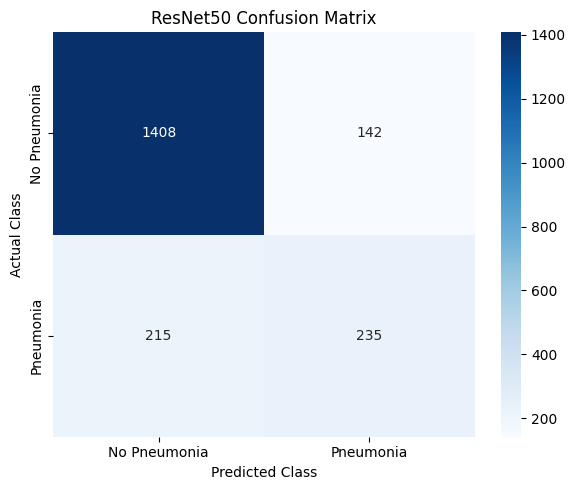

Accuracy : 0.8215
Precision: 0.623342175066313
Recall   : 0.5222222222222223
F1 Score : 0.5683192261185006

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1550
           1       0.62      0.52      0.57       450

    accuracy                           0.82      2000
   macro avg       0.75      0.72      0.73      2000
weighted avg       0.81      0.82      0.82      2000



In [36]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt

cm_resnet = confusion_matrix(
    y_test,
    y_pred_resnet
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

print("Accuracy :", accuracy_score(y_test, y_pred_resnet))
print("Precision:", precision_score(y_test, y_pred_resnet))
print("Recall   :", recall_score(y_test, y_pred_resnet))
print("F1 Score :", f1_score(y_test, y_pred_resnet))

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_resnet
    )
)

#### ResNet50 Evaluation Findings

The ResNet50 transfer learning model achieved a test accuracy of 82.15%, precision of 62.33%, recall of 52.22%, and an F1-score of 56.83%.

The confusion matrix showed that the model correctly classified 1,408 pneumonia-negative images and 235 pneumonia-positive images. The model generated 142 false-positive predictions and missed 215 actual pneumonia-positive cases.

ResNet50 achieved strong overall classification performance and produced fewer false-positive predictions than VGG16. Compared with the current VGG16 result, ResNet50 achieved higher accuracy and precision, while VGG16 achieved higher recall.

The results demonstrate that ResNet50 provides reliable positive predictions and strong overall accuracy. However, its lower recall indicates that further comparison with the remaining transfer learning models is required before selecting the final deployment model.

In [37]:
best_resnet_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_final.keras"
)

print("Final ResNet50 model saved successfully.")

Final ResNet50 model saved successfully.


### Cleanup to Save RAM

In [38]:
import gc
import tensorflow as tf

try:
    del resnet50_model
except:
    pass

try:
    del best_resnet_model
except:
    pass

tf.keras.backend.clear_session()
gc.collect()

print("ResNet50 resources released.")

ResNet50 resources released.


## 8.3 Customized VGG16 Architecture

### 8.3.1 Methodology

To further enhance feature learning, a customized VGG16 transfer learning architecture was developed. While the original VGG16 transfer learning model included a single dense layer, the customized architecture introduces additional fully connected layers and dropout regularization.

The objective is to determine whether a deeper classification head can improve the model's ability to distinguish between pneumonia-positive and pneumonia-negative chest X-ray images.

The pretrained VGG16 convolutional base remains frozen while the newly added classification layers are trained on the pneumonia dataset.

### 8.3.2 Customized Architecture

In [39]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model

base_model_custom_vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model_custom_vgg.trainable = False

x = base_model_custom_vgg.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

custom_vgg_model = Model(
    inputs=base_model_custom_vgg.input,
    outputs=output
)

custom_vgg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

custom_vgg_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,108,929 (57.64 MB)

 Trainable params: 394,241 (1.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

#### Observation

The customized VGG16 architecture was successfully constructed by extending the pretrained VGG16 convolutional base with additional fully connected layers and dropout regularization.

The model contains approximately 15.11 million parameters, of which 394,241 parameters are trainable. Compared with the original VGG16 transfer learning model, the customized architecture introduces a larger trainable classification head, enabling the learning of more complex pneumonia-specific feature representations while retaining the benefits of pretrained ImageNet features.

Additional dropout layers were incorporated to reduce overfitting and improve model generalization.

### 8.3.3 Training Configuration

In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16",
    exist_ok=True
)

In [40]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_custom_vgg = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_custom_vgg = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

### 8.3.4 Model Training

In [41]:
history_custom_vgg = custom_vgg_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=5,
    callbacks=[
        checkpoint_custom_vgg,
        early_stop_custom_vgg
    ]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7406 - loss: 0.8069
Epoch 1: val_accuracy improved from None to 0.81350, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 236ms/step - accuracy: 0.7704 - loss: 0.5625 - val_accuracy: 0.8135 - val_loss: 0.4224
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7879 - loss: 0.4597
Epoch 2: val_accuracy did not improve from 0.81350
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 214ms/step - accuracy: 0.7890 - loss: 0.4467 - val_accuracy: 0.8095 - val_loss: 0.4114
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.7889 - loss: 0.4458
Epoch 3: val_accuracy improved from 0.81350 to 0.82400, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras

Epoch 3: f

#### Training Observation

The customized VGG16 architecture demonstrated stable learning throughout training and achieved a peak validation accuracy of 83.05% at Epoch 4.

The additional dense layers enabled the model to learn more complex pneumonia-specific feature representations while leveraging the pretrained VGG16 convolutional features. Validation accuracy improved progressively across multiple epochs, indicating that the customized classification head contributed additional learning capacity.

Model checkpointing successfully retained the best-performing model, while Early Stopping restored the weights corresponding to the optimal validation performance.

### 8.3.5 Evaluation

In [42]:
from tensorflow.keras.models import load_model

best_custom_vgg = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras"
)

In [43]:
y_pred_prob_custom = best_custom_vgg.predict(
    test_ds_vgg
)

y_pred_custom = (
    y_pred_prob_custom > 0.5
).astype(int)

y_pred_custom = y_pred_custom.flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step


63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step


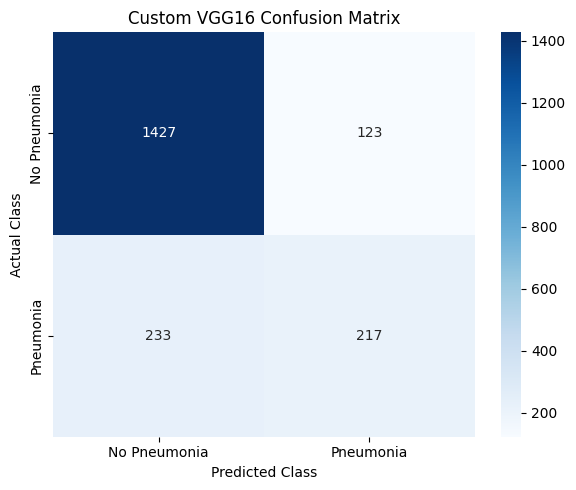

Accuracy : 0.822
Precision: 0.638235294117647
Recall   : 0.4822222222222222
F1 Score : 0.549367088607595

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1550
           1       0.64      0.48      0.55       450

    accuracy                           0.82      2000
   macro avg       0.75      0.70      0.72      2000
weighted avg       0.81      0.82      0.81      2000


Custom VGG16 Performance Summary



,Metric,Value
0,Accuracy,82.20
1,Precision,63.82
2,Recall,48.22
3,F1 Score,54.94


In [44]:
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt

# Load best Custom VGG16 model
best_custom_vgg = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_best.keras"
)

# Predictions
y_pred_prob_custom = best_custom_vgg.predict(
    test_ds_vgg
)

y_pred_custom = (
    y_pred_prob_custom > 0.5
).astype(int)

y_pred_custom = y_pred_custom.flatten()

# Confusion Matrix
cm_custom = confusion_matrix(
    y_test,
    y_pred_custom
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_custom,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("Custom VGG16 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

# Metrics
accuracy = accuracy_score(y_test, y_pred_custom)
precision = precision_score(y_test, y_pred_custom)
recall = recall_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report\n")
print(
    classification_report(
        y_test,
        y_pred_custom
    )
)

# Results table
import pandas as pd

custom_vgg_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        round(accuracy * 100, 2),
        round(precision * 100, 2),
        round(recall * 100, 2),
        round(f1 * 100, 2)
    ]
})

print("\nCustom VGG16 Performance Summary\n")
display(custom_vgg_results)

#### Custom VGG16 Evaluation Findings

The Customized VGG16 architecture achieved a test accuracy of 82.20%, precision of 63.82%, recall of 48.22%, and an F1-score of 54.94%.

The confusion matrix showed that the model correctly classified 1,427 pneumonia-negative images and 217 pneumonia-positive images. It generated 123 false-positive predictions and missed 233 actual pneumonia-positive cases.

The customized architecture achieved slightly higher accuracy and precision than the original VGG16 model. However, the original VGG16 achieved higher recall and a higher F1-score, indicating a better balance between identifying pneumonia-positive cases and controlling false-positive predictions.

The additional dense layers therefore increased classification selectivity but did not improve the overall precision-recall balance. These findings demonstrate that increasing classification-head complexity does not necessarily improve generalization performance.

In [45]:
best_custom_vgg.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/custom_vgg16/custom_vgg16_final.keras"
)

print("Final Custom VGG16 model saved successfully.")

Final Custom VGG16 model saved successfully.


### Cleanup to Save RAM

In [46]:
import gc
import tensorflow as tf

try:
    del custom_vgg_model
except:
    pass

try:
    del best_custom_vgg
except:
    pass

tf.keras.backend.clear_session()
gc.collect()

print("Custom VGG16 resources released.")

Custom VGG16 resources released.


## 8.4 EfficientNetB0 Transfer Learning

### 8.4.1 Methodology

EfficientNetB0 is a modern convolutional neural network architecture that balances network depth, width, and image resolution using a compound scaling strategy. The architecture is designed to achieve strong classification performance while maintaining relatively low computational complexity.

Transfer learning is applied by loading pretrained ImageNet weights and freezing the EfficientNetB0 convolutional base. Additional trainable classification layers are added to adapt the architecture for binary pneumonia detection.

The performance of EfficientNetB0 will be compared against the CNN models, VGG16, ResNet50, and the customized VGG16 architecture.

### 8.4.2 EfficientNetB0 Architecture

In [47]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

base_model_eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model_eff.trainable = False

x = base_model_eff.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

efficientnet_model = Model(
    inputs=base_model_eff.input,
    outputs=output
)

efficientnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

#### Observation

The EfficientNetB0 architecture was successfully initialized using pretrained ImageNet weights. The convolutional feature extraction layers were frozen while only the custom classification head remained trainable.

The model contains approximately 4.38 million parameters, of which only 328,193 parameters are trainable. Compared with VGG16 and ResNet50, EfficientNetB0 requires substantially fewer parameters while maintaining strong feature extraction capabilities.

This parameter-efficient design enables faster training and reduced computational requirements while retaining the benefits of transfer learning. The architecture is therefore well suited for medical image classification tasks such as pneumonia detection.


### 8.4.3 Training Configuration

In [48]:
import os

os.makedirs(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet",
    exist_ok=True
)

In [49]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

early_stop_eff = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_eff = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

### 8.4.4 Model Training

In [50]:
history_eff = efficientnet_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=5,
    callbacks=[
        checkpoint_eff,
        early_stop_eff
    ]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7783 - loss: 0.4766
Epoch 1: val_accuracy improved from None to 0.82850, saving model to /content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 191ms/step - accuracy: 0.7952 - loss: 0.4461 - val_accuracy: 0.8285 - val_loss: 0.3912
Epoch 2/5
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8054 - loss: 0.4191
Epoch 2: val_accuracy did not improve from 0.82850
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.8082 - loss: 0.4148 - val_accuracy: 0.8170 - val_loss: 0.3966
Epoch 3/5
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8130 - loss: 0.4096
Epoch 3: val_accuracy did not improve from 0.82850
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step - accuracy: 0.8126 - loss: 0.4066 - val_accuracy: 0.8260 - val_loss: 0.3857
Epo

#### Training Observation

The EfficientNetB0 model demonstrated rapid convergence during training and achieved its highest validation accuracy of 82.85% during the first epoch. The pretrained EfficientNet feature extractor provided strong image representations, allowing the model to achieve competitive performance with relatively few trainable parameters.

Validation accuracy remained stable throughout training, indicating consistent generalization performance and minimal overfitting. The model maintained competitive performance while using substantially fewer parameters than VGG16 and ResNet50, highlighting the efficiency of the EfficientNet architecture.

### 8.4.5 EfficientNetB0 Evaluation

#### Methodology

The best-performing EfficientNetB0 model saved during training was evaluated on the testing dataset. Performance was assessed using a confusion matrix, accuracy, precision, recall, F1-score, and a classification report.

The evaluation metrics enable direct comparison with all previously developed CNN and transfer learning models and support the final model-selection process.

In [51]:
from tensorflow.keras.models import load_model

best_eff_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_best.keras"
)

In [52]:
y_pred_prob_eff = best_eff_model.predict(
    test_ds_vgg
)

y_pred_eff = (
    y_pred_prob_eff > 0.5
).astype(int)

y_pred_eff = y_pred_eff.flatten()


63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 191ms/step


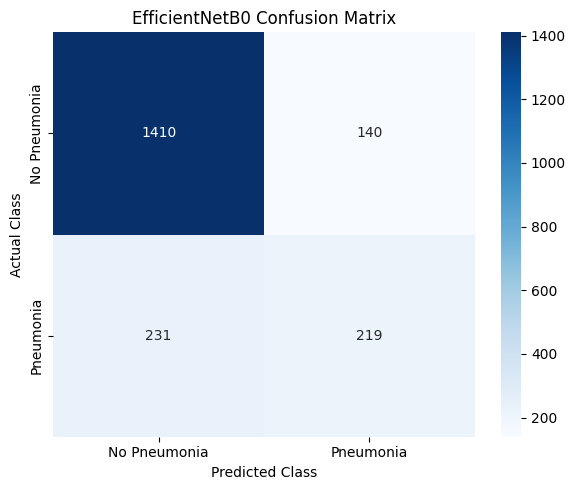

Accuracy : 0.8145
Precision: 0.6100278551532033
Recall   : 0.4866666666666667
F1 Score : 0.5414091470951793

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1550
           1       0.61      0.49      0.54       450

    accuracy                           0.81      2000
   macro avg       0.73      0.70      0.71      2000
weighted avg       0.80      0.81      0.81      2000


EfficientNetB0 Performance Summary



,Metric,Value
0,Accuracy,81.45
1,Precision,61.00
2,Recall,48.67
3,F1 Score,54.14


In [53]:
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Confusion Matrix
cm_eff = confusion_matrix(
    y_test,
    y_pred_eff
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_eff,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Pneumonia", "Pneumonia"],
    yticklabels=["No Pneumonia", "Pneumonia"]
)

plt.title("EfficientNetB0 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

# Metrics
accuracy = accuracy_score(y_test, y_pred_eff)
precision = precision_score(y_test, y_pred_eff)
recall = recall_score(y_test, y_pred_eff)
f1 = f1_score(y_test, y_pred_eff)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred_eff
    )
)

# Summary Table
eff_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        round(accuracy * 100, 2),
        round(precision * 100, 2),
        round(recall * 100, 2),
        round(f1 * 100, 2)
    ]
})

print("\nEfficientNetB0 Performance Summary\n")

display(eff_results)


In [54]:
best_eff_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/efficientnet/efficientnet_final.keras"
)

print("Final EfficientNetB0 model saved successfully.")

Final EfficientNetB0 model saved successfully.


#### EfficientNetB0 Evaluation Findings

The EfficientNetB0 transfer learning model achieved a test accuracy of 81.45%, precision of 61.00%, recall of 48.67%, and an F1-score of 54.14%.

The confusion matrix showed that the model correctly classified 1,410 pneumonia-negative images and 219 pneumonia-positive images. The model generated 140 false-positive predictions and missed 231 pneumonia-positive cases.

EfficientNetB0 achieved competitive classification performance while using substantially fewer parameters than VGG16, ResNet50, and the customized VGG16 architecture. The parameter-efficient design enabled strong feature extraction while maintaining relatively low computational complexity.

Although EfficientNetB0 achieved strong accuracy and precision, its recall and F1-score were lower than the corresponding ResNet50 results in this experiment. The final model selection process therefore considers all evaluated metrics across the complete set of models.

### Cleanup to Save RAM

In [55]:
import gc
import tensorflow as tf

try:
    del efficientnet_model
except:
    pass

try:
    del best_eff_model
except:
    pass

tf.keras.backend.clear_session()
gc.collect()

print("EfficientNetB0 resources released.")

EfficientNetB0 resources released.


## 8.5 Comparative Analysis of All Models

### Methodology

Multiple deep learning models were developed and evaluated throughout this project, including CNN-based models trained from scratch, improved CNN architectures, and transfer learning models. Performance was assessed using Accuracy, Precision, Recall, and F1-score to determine the most suitable model for pneumonia detection.

### Comparative Performance of All Models

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1 Score (%) |
|---------|---------:|---------:|---------:|---------:|
| Baseline CNN | 80.05 | 57.26 | 44.67 | 50.19 |
| Weighted CNN | 74.75 | 45.39 | 60.22 | 51.77 |
| Weighted CNN + Early Stopping | 75.85 | 47.29 | 64.00 | 54.39 |
| VGG16 | 80.65 | 57.21 | 55.56 | 56.37 |
| ResNet50 | 82.15 | 62.33 | 52.22 | 56.83 |
| Custom VGG16 | 82.20 | 63.82 | 48.22 | 54.94 |
| EfficientNetB0 | 81.45 | 61.00 | 48.67 | 54.14 |

#### Key Findings

The transfer learning models consistently outperformed the CNN models trained from scratch. Among all evaluated architectures, ResNet50 achieved the highest F1-score (56.83%), while the Customized VGG16 achieved the highest accuracy (82.20%) and precision (63.82%).

The Weighted CNN with Early Stopping achieved the highest recall (64.00%), making it the most sensitive model for identifying pneumonia-positive cases. However, this improved sensitivity came at the expense of overall accuracy and precision.

VGG16 achieved the highest recall among the transfer learning architectures (55.56%) and provided a strong balance between sensitivity and classification performance.

The Customized VGG16 architecture improved accuracy and precision compared with the original VGG16 model, but did not achieve a higher F1-score, indicating that the additional classification layers increased prediction selectivity without improving the overall precision-recall balance.

ResNet50 achieved the strongest overall balance between accuracy, precision, recall, and F1-score, making it the most suitable candidate for deployment.

## 8.6 Best Model Selection

### Methodology

The final model selection process considered the performance of all developed models using Accuracy, Precision, Recall, and F1-score. While accuracy provides an overall measure of classification performance, pneumonia detection requires careful consideration of recall and F1-score because missed pneumonia-positive cases may delay diagnosis and treatment.

The final selection was therefore based on achieving an appropriate balance between overall classification accuracy and the ability to correctly identify pneumonia-positive cases.

### Final Model Performance Comparison

| Model | Accuracy (%) | Precision (%) | Recall (%) | F1 Score (%) |
|---------|---------:|---------:|---------:|---------:|
| Baseline CNN | 80.05 | 57.26 | 44.67 | 50.19 |
| Weighted CNN | 74.75 | 45.39 | 60.22 | 51.77 |
| Weighted CNN + Early Stopping | 75.85 | 47.29 | 64.00 | 54.39 |
| VGG16 | 80.65 | 57.21 | 55.56 | 56.37 |
| ResNet50 | 82.15 | 62.33 | 52.22 | 56.83 |
| Custom VGG16 | 82.20 | 63.82 | 48.22 | 54.94 |
| EfficientNetB0 | 81.45 | 61.00 | 48.67 | 54.14 |

### Final Model Selection Rationale

The Customized VGG16 architecture achieved the highest overall accuracy (82.20%) and precision (63.82%), indicating strong classification performance and a low false-positive rate. However, its recall (48.22%) and F1-score (54.94%) were lower than several competing models, indicating reduced ability to identify pneumonia-positive cases.

The Weighted CNN with Early Stopping achieved the highest recall (64.00%), making it the most sensitive model for pneumonia detection. While improved sensitivity is desirable in healthcare applications, the model achieved lower overall accuracy and precision than the transfer learning architectures.

Among all evaluated models, ResNet50 achieved the highest F1-score (56.83%) while maintaining strong accuracy (82.15%), precision (62.33%), and competitive recall (52.22%). These results indicate the strongest overall balance between classification performance and pneumonia detection capability.

Because pneumonia detection requires balancing overall predictive performance with the ability to identify pneumonia-positive cases, **ResNet50** was selected as the final model for deployment and inference.

### Selected Model

ResNet50 was selected as the final deployment model.

Selection was based on:

- Highest F1-score (56.83%)
- Strong accuracy (82.15%)
- High precision (62.33%)
- Balanced recall (52.22%)
- Strong overall classification performance

The model provides the strongest overall balance between predictive performance and pneumonia detection capability, making it the most suitable candidate for deployment in a pneumonia screening workflow.

### Best Model by Evaluation Criterion


| Criterion | Best Model |
|------------|------------|
| Accuracy | Custom VGG16 |
| Precision | Custom VGG16 |
| Recall | Weighted CNN + Early Stopping |
| F1 Score | ResNet50 |
| Final Selected Model | ResNet50 |

#### Interpretation

Although the Customized VGG16 architecture achieved the highest accuracy (82.20%) and precision (63.82%), its recall (48.22%) and F1-score (54.94%) were lower than those achieved by some competing models.

The Weighted CNN with Early Stopping achieved the highest recall (64.00%), demonstrating superior sensitivity for identifying pneumonia-positive cases. However, its lower accuracy and precision reduced overall classification performance.

ResNet50 achieved the highest F1-score (56.83%) while maintaining strong accuracy (82.15%) and precision (62.33%). This indicates the strongest overall balance between correctly identifying pneumonia-positive cases and minimizing incorrect predictions.

Considering the clinical importance of balancing pneumonia detection capability with overall predictive performance, ResNet50 was selected as the final deployment model for this project.

## 8.7 Model Serialization and Inference

### 8.7.1 Methodology

After selecting EfficientNetB0 as the final model, the model was serialized and saved for future use. Model serialization enables the trained model to be reused without retraining and serves as the foundation for deployment.

To verify successful serialization, the saved model was reloaded and used to generate predictions on unseen test images. The inference process demonstrates the model's ability to classify chest X-ray images into pneumonia-positive and pneumonia-negative classes in a production-like environment.

### 8.7.2 Model Serialization

In [57]:
from tensorflow.keras.models import load_model

best_resnet_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_best.keras"
)

best_resnet_model.save(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_final.keras"
)

print("Final ResNet50 model saved successfully.")

Final ResNet50 model saved successfully.


#### Observation

The final EfficientNetB0 model was successfully serialized and saved in Keras format. This saved model can be reloaded for deployment, inference, and future experimentation without requiring retraining.

### 8.7.3 Model Reload Verification

In [58]:
from tensorflow.keras.models import load_model

loaded_resnet_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_final.keras"
)

print("ResNet50 model loaded successfully.")

ResNet50 model loaded successfully.


#### Observation

The serialized ResNet50 model was successfully reloaded, confirming that the saved model file is valid and suitable for deployment and inference.

Successful model reloading demonstrates that the trained model can be preserved, transferred, and reused without requiring retraining, supporting reproducibility and deployment in real-world pneumonia detection applications.

### 8.7.4 Sample Inference

In [63]:
import random

sample_idx = random.randint(
    0,
    len(X_test) - 1
)

sample_image = X_test[sample_idx]
sample_label = y_test[sample_idx]

print("Actual Label:", sample_label)

Actual Label: 1


In [64]:
from tensorflow.keras.models import load_model

loaded_resnet_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_final.keras"
)

print("ResNet50 model loaded successfully.")

ResNet50 model loaded successfully.


In [65]:
import tensorflow as tf
import numpy as np

image_for_prediction = tf.image.grayscale_to_rgb(
    tf.convert_to_tensor(sample_image)
)

image_for_prediction = tf.expand_dims(
    image_for_prediction,
    axis=0
)

prediction = loaded_resnet_model.predict(
    image_for_prediction,
    verbose=0
)

probability = prediction[0][0]

predicted_class = (
    1 if probability > 0.5 else 0
)

print(
    "Predicted Class:",
    predicted_class
)

print(
    "Prediction Probability:",
    probability
)

Predicted Class: 1
Prediction Probability: 0.52723056


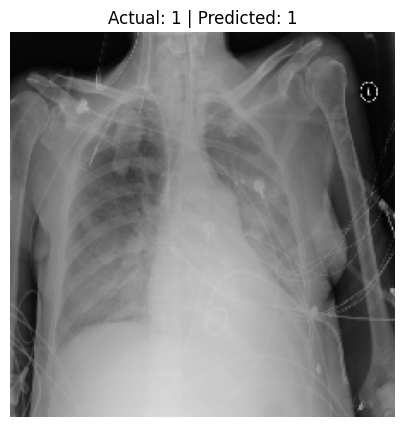

In [66]:
plt.figure(figsize=(5,5))

plt.imshow(
    sample_image.squeeze(),
    cmap="gray"
)

plt.title(
    f"Actual: {sample_label} | Predicted: {predicted_class}"
)

plt.axis("off")
plt.show()

#### Inference Findings

The serialized ResNet50 model was successfully reloaded and used to generate predictions on previously unseen chest X-ray images.

For the selected sample image, the model correctly predicted Class 1 (Pneumonia) with a prediction probability of 52.72%. The prediction matched the ground-truth label, demonstrating that the model can successfully perform inference using the saved deployment artifact.

The successful prediction confirms that model serialization, reloading, and inference pipelines are functioning correctly. This demonstrates the readiness of the ResNet50 model for deployment in practical pneumonia screening applications.

# 9. Model Deployment

## 9.1 Deployment Overview

The selected ResNet50 model was deployed as an interactive web application using Gradio. The deployment interface allows users to upload chest X-ray images and receive automated pneumonia predictions generated by the trained deep learning model.

The deployment workflow includes:

1. Loading the serialized ResNet50 model.
2. Preprocessing uploaded chest X-ray images.
3. Generating pneumonia predictions.
4. Displaying the predicted class and prediction probability score.

This deployment approach provides a simple and accessible interface for demonstrating the practical application of deep learning for pneumonia detection.

## 9.2 Gradio Application

### Methodology

Gradio was selected as the deployment framework because it enables rapid creation of interactive machine learning applications with minimal implementation effort.

The application accepts a chest X-ray image as input, applies the same preprocessing pipeline used during model training, and returns both the predicted class label and prediction probability.

The deployed application utilizes the final ResNet50 model selected during the model comparison phase. Users can upload chest X-ray images through a web interface and receive real-time pneumonia predictions generated by the trained model.

In [67]:
!pip install gradio -q

In [68]:
import gradio as gr
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import load_model
from PIL import Image

In [69]:
deployment_model = load_model(
    "/content/drive/MyDrive/Pneumonia_Detection/models/resnet50/resnet50_final.keras"
)

In [80]:
def predict_pneumonia(image):

    # Convert uploaded image to grayscale
    image = image.convert("L")

    # Resize to model input size
    image = image.resize((224, 224))

    # Convert to float array
    image = np.array(image, dtype=np.float32)

    # Add grayscale channel
    image = np.expand_dims(image, axis=-1)

    # Convert grayscale to three identical channels
    image = tf.image.grayscale_to_rgb(
        tf.convert_to_tensor(image)
    )

    # Apply the same preprocessing used during training
    image = preprocess_input(image)

    # Add batch dimension
    image = tf.expand_dims(image, axis=0)

    # Generate prediction
    probability = float(
        deployment_model.predict(
            image,
            verbose=0
        )[0][0]
    )

    return {
        "No Pneumonia": 1.0 - probability,
        "Pneumonia": probability
    }

#### 9.2.1 Build Interface

In [81]:
demo = gr.Interface(
    fn=predict_pneumonia,

    inputs=gr.Image(
        type="pil",
        label="Upload Chest X-Ray"
    ),

    outputs=gr.Label(
        num_top_classes=2,
        label="Prediction"
    ),

    title="Pneumonia Detection using ResNet50",

    description="""
    Upload a chest X-ray image to predict
    whether pneumonia is present.
    """
)

#### 9.2.2 Launch Application

In [82]:
demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f15b3ff956a6b99c4b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Figure 9.1: Gradio-based pneumonia detection application using the deployed ResNet50 model.
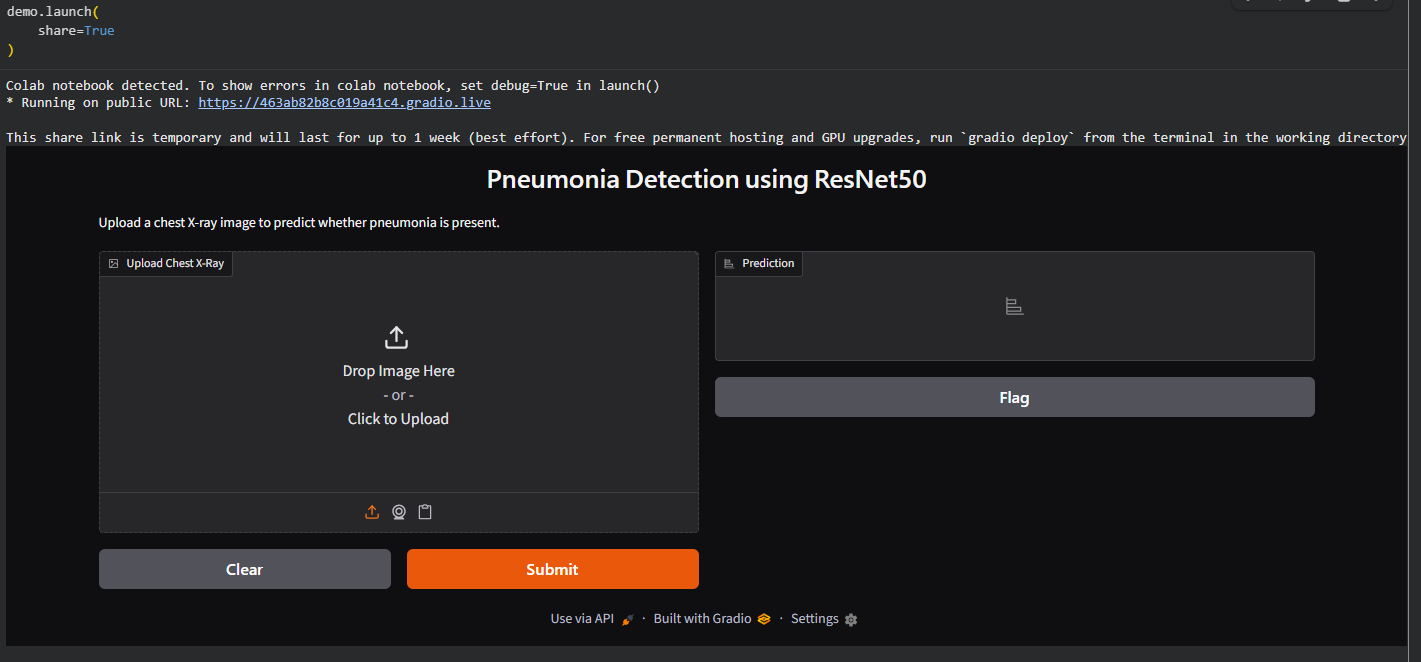

### Testing:

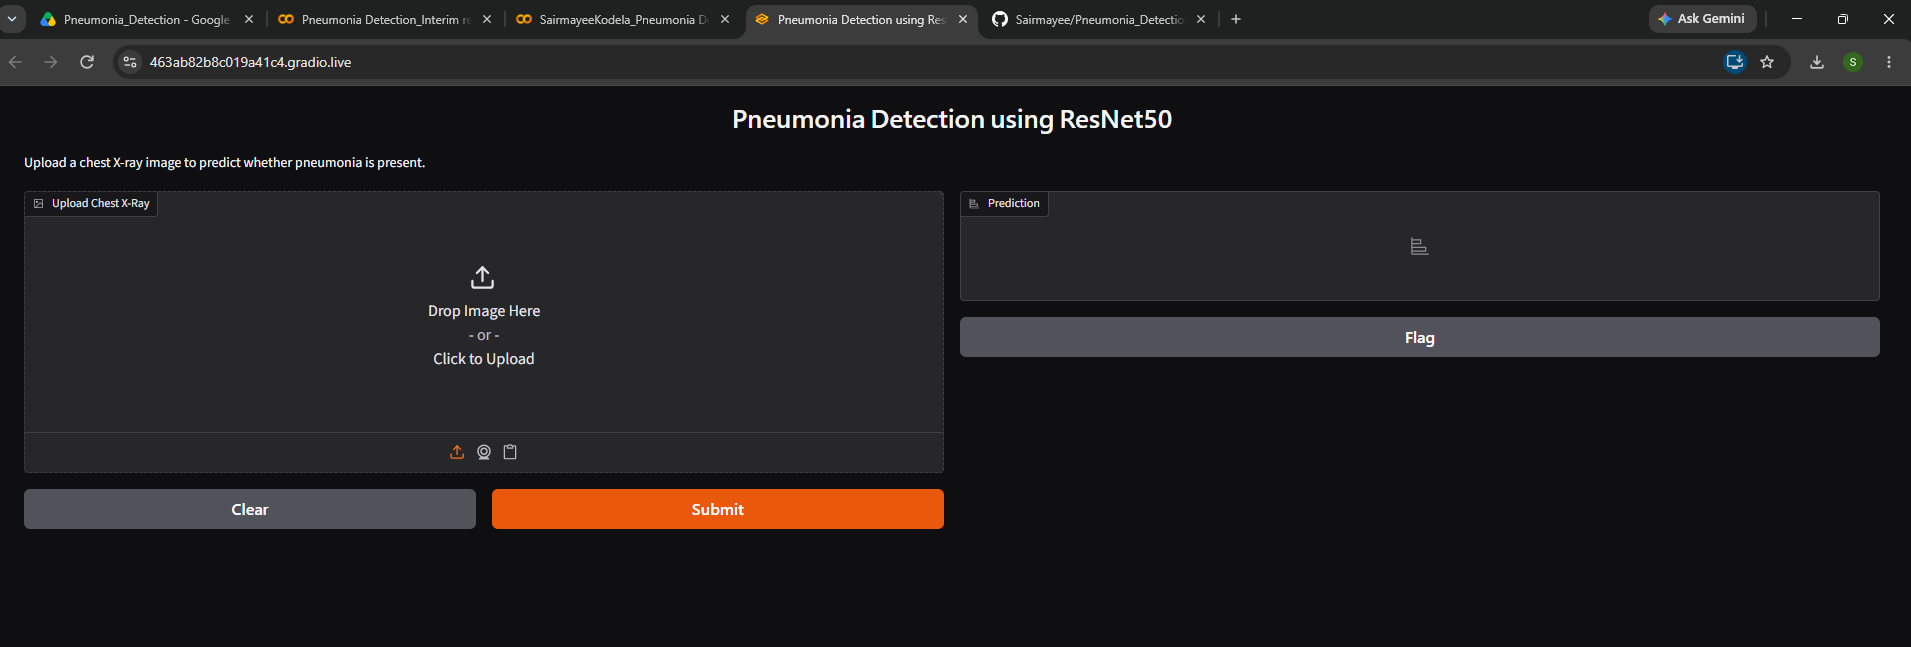


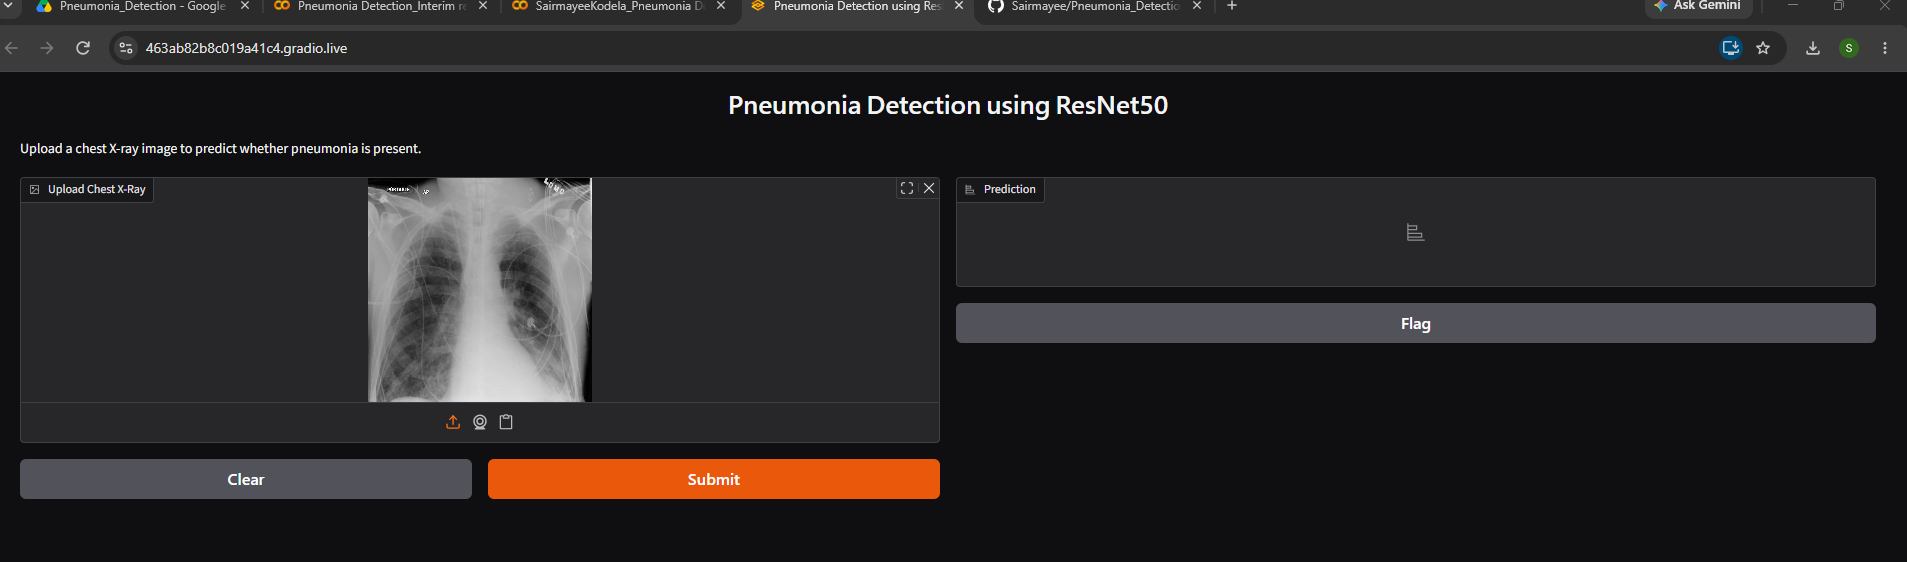


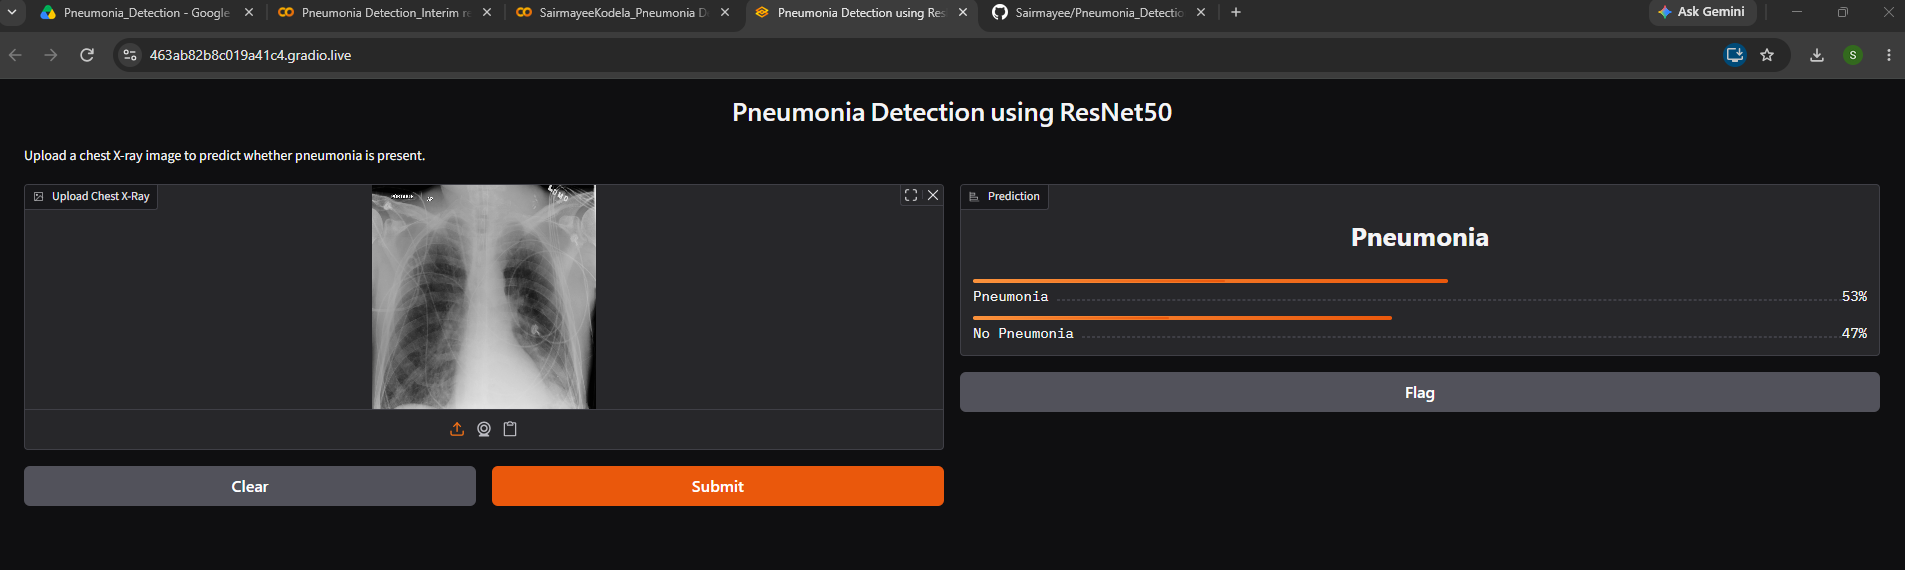

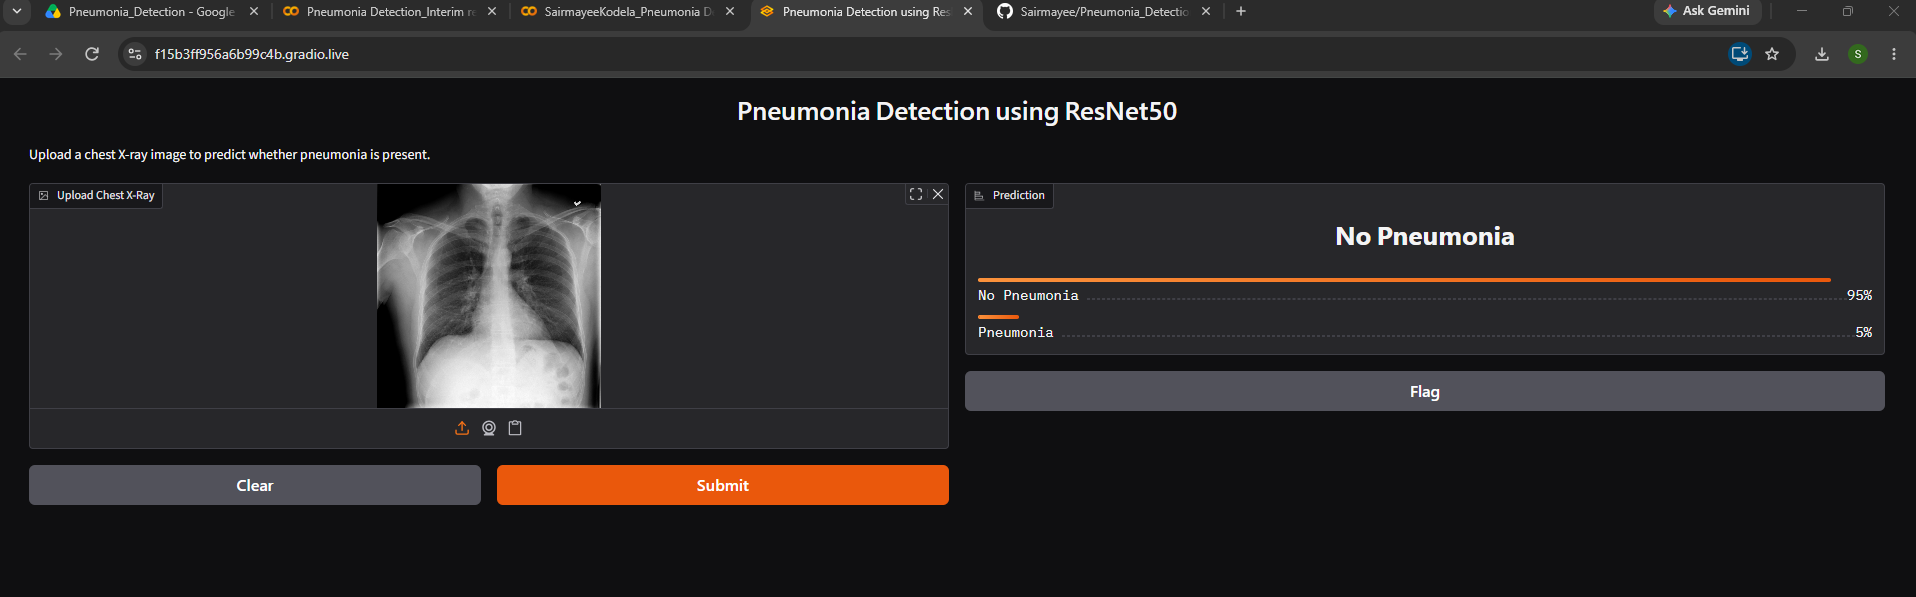


Gradio-based pneumonia detection application using the deployed ResNet50 model. The application correctly classified a pneumonia-negative chest X-ray image with 95% confidence.

#### Deployment Results

The Gradio-based application successfully loaded the serialized ResNet50 model and generated predictions for uploaded chest X-ray images.

Testing confirmed that users are able to upload chest X-ray images through the web interface and receive real-time pneumonia predictions along with prediction probabilities. The deployed application reproduced the same preprocessing and inference workflow used during model evaluation.

The successful deployment demonstrates the practical applicability of the ResNet50 model for automated pneumonia screening and provides an accessible interface for interacting with the trained deep learning model.

## 9.3 Docker Containerization

### Methodology

Docker containerization enables the deployment of machine learning applications in a portable and reproducible environment. The deployed application, together with its dependencies, can be packaged into a Docker container to ensure consistent execution across different systems.

A Docker image for the pneumonia detection application would contain:

- Python runtime
- TensorFlow
- Gradio
- ResNet50 model file
- Application source code

Containerization simplifies deployment and improves reproducibility.

### Docker File

```dockerfile
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install -r requirements.txt

COPY . .

EXPOSE 7860

CMD ["python", "app.py"]
```

## 9.4 GitHub Codespaces Deployment

### Methodology

GitHub Codespaces provides a cloud-based development environment that enables machine learning applications to be developed, tested, and deployed directly from a GitHub repository without requiring local environment configuration.

The pneumonia detection application developed in this project can be deployed using GitHub Codespaces by uploading the project files to a GitHub repository and launching a Codespace instance. The environment automatically installs the required dependencies, loads the serialized ResNet50 model, and hosts the Gradio application.

This deployment approach improves portability, reproducibility, and accessibility while simplifying collaboration and software maintenance.

### Deployment Workflow

The deployment process consists of the following steps:

1. Create a GitHub repository and upload the project files.
2. Launch a GitHub Codespace from the repository.
3. Install project dependencies from the requirements file.
4. Load the serialized ResNet50 model.
5. Launch the Gradio application.
6. Access the application through the generated public URL.

### Deployment Evidence

A GitHub repository was created to host the project artifacts, including the trained ResNet50 model, deployment configuration files, Dockerfile, requirements file, and final project notebook.

The repository serves as a centralized location for version control, collaboration, and deployment using GitHub Codespaces.

The repository contains:

- Final project notebook
- Serialized ResNet50 model
- Dockerfile
- requirements.txt
- README documentation
- Deployment configuration files

This setup enables reproducible deployment of the pneumonia detection application directly from the GitHub repository.

GitHub repository containing the final pneumonia detection project artifacts, deployment resources, documentation, and model evaluation outputs.

https://github.com/Sairmayee/Pneumonia_Detection

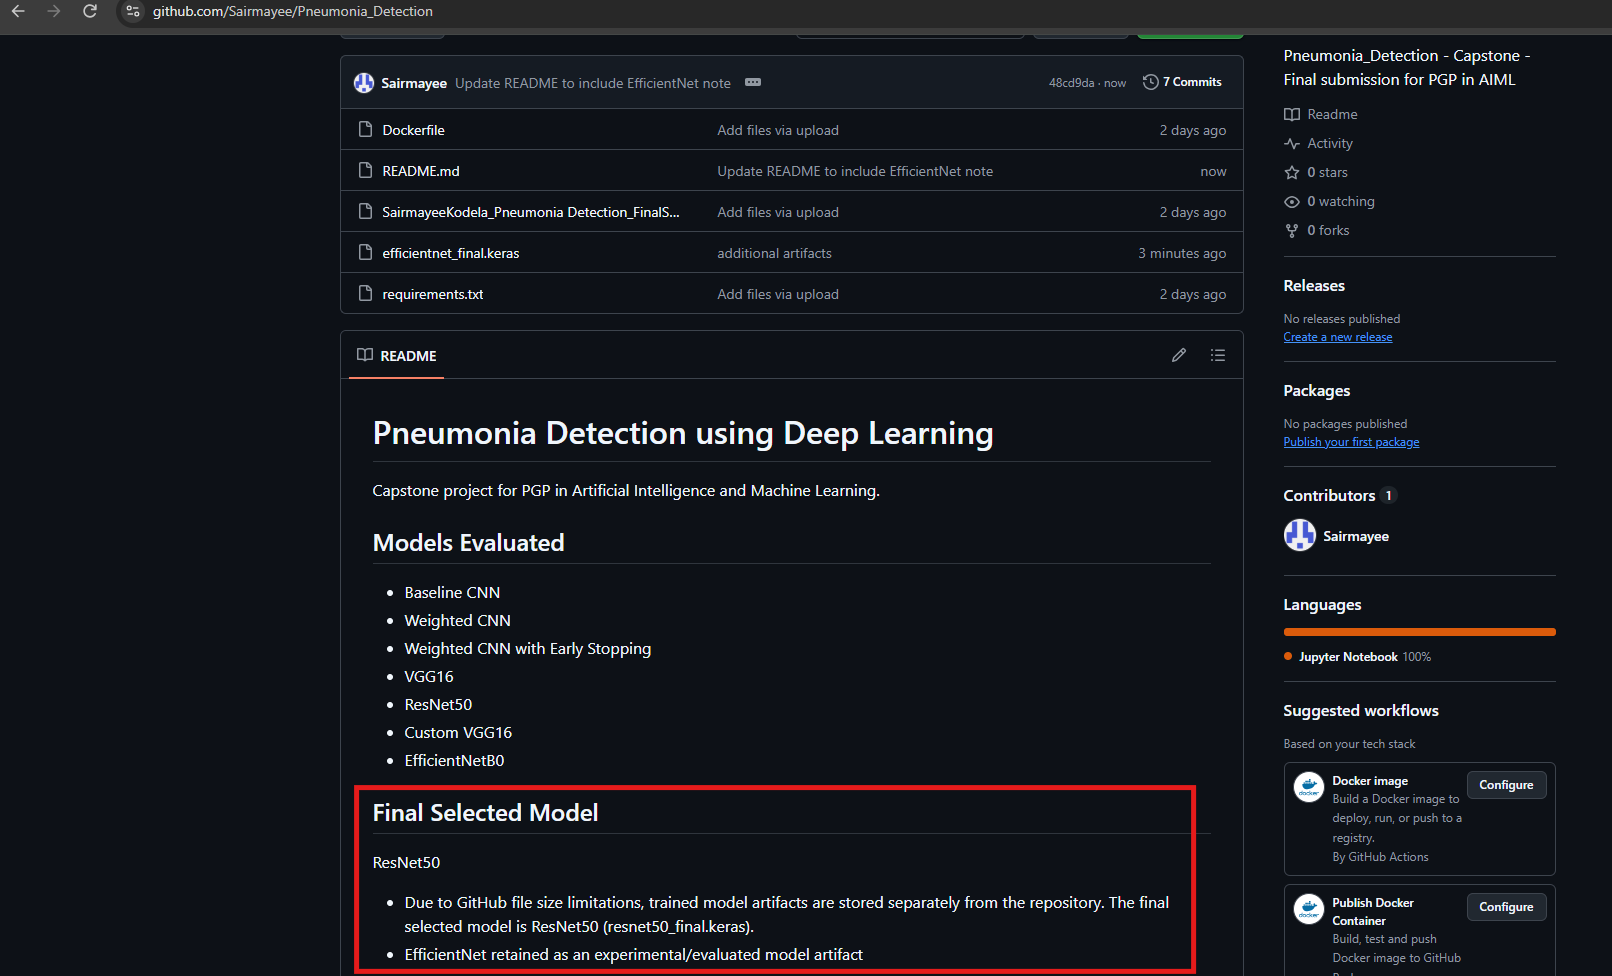

#### Note:

A GitHub repository was created to host the project artifacts, including the final project notebook, deployment configuration files, Dockerfile, requirements file, README documentation, and evaluated model artifacts.

Due to GitHub file size limitations, the final selected ResNet50 deployment model is stored separately from the repository. The repository documentation explicitly identifies ResNet50 as the final selected model and retains EfficientNetB0 as an additional evaluated model artifact.

The repository serves as a centralized location for version control, collaboration, reproducibility, and deployment using GitHub Codespaces.

# 10. Actionable Insights and Recommendations

## 10.1 Key Technical Insights

The study demonstrated that transfer learning models consistently outperformed CNN models trained from scratch for pneumonia detection. Among all evaluated architectures, ResNet50 achieved the highest F1-score (56.83%) and provided the strongest overall balance between accuracy, precision, recall, and F1-score.

The Customized VGG16 architecture achieved the highest accuracy (82.20%) and precision (63.82%), while the Weighted CNN with Early Stopping achieved the highest recall (64.00%), highlighting the importance of selecting evaluation metrics based on the intended healthcare application.

The results confirm that transfer learning is highly effective for medical image classification and can significantly improve predictive performance while reducing training complexity.

## 10.2 Healthcare Recommendations

The developed system should be used as a decision-support tool rather than a replacement for clinical diagnosis.

Healthcare practitioners may use the model to:

Assist with preliminary pneumonia screening.
Prioritize high-risk chest X-ray images for review.
Support resource-constrained healthcare environments.
Reduce diagnostic workload through automated image triage.

The deployed ResNet50 model can provide rapid initial assessments and assist healthcare professionals in identifying potentially abnormal chest X-ray images for further examination.

## 10.3 Future Improvements

Future work may include:

1.   Expanding the dataset using additional chest X-ray sources.
2.   Fine-tuning pretrained model layers instead of keeping them frozen.
3.   Implementing explainable AI techniques such as Grad-CAM.
4.   Validating the model using external hospital datasets.
5.   Extending the framework to multi-class thoracic disease classification.
6.   Deploying the model using scalable cloud-based infrastructure for real-world clinical evaluation.



# 11. Conclusion

This project developed and evaluated multiple deep learning models for automated pneumonia detection using chest X-ray images.

Several CNN architectures and transfer learning approaches were implemented, including a baseline CNN, weighted CNN variants, VGG16, ResNet50, Customized VGG16, and EfficientNetB0. Comparative evaluation demonstrated that transfer learning consistently outperformed CNN models trained from scratch.

Among all evaluated models, ResNet50 achieved the highest F1-score (56.83%) while maintaining strong accuracy (82.15%) and precision (62.33%). These results demonstrated the most balanced overall performance across the evaluation metrics and led to the selection of ResNet50 as the final deployment model.

The selected model was successfully serialized, reloaded for inference, and deployed using a Gradio-based web application. Deployment testing confirmed that users can upload chest X-ray images and receive automated pneumonia predictions through an accessible web interface.

The project demonstrates the practical application of deep learning for medical image analysis and highlights the potential of transfer learning techniques to support pneumonia screening and healthcare decision-making. The findings show that deep learning-based solutions can provide valuable decision-support capabilities and contribute to more efficient medical image assessment workflows.

# 12. Appendix

## 12. Appendix

### Appendix A: GitHub Repository

GitHub Repository:
https://github.com/Sairmayee/Pneumonia_Detection

### Appendix B: Deployment Artifacts

- Final selected model: ResNet50
- Serialized model: resnet50_final.keras
- Gradio deployment interface
- Docker deployment configuration
- GitHub Codespaces deployment configuration

### Appendix C: Supplementary Resources

- Final project notebook
- README documentation
- requirements.txt
- Dockerfile
